In [1]:
import pandas as pd

df = pd.read_excel('/content/dataframe_procesado.xlsx')

# Convertir los nombres de las columnas a minúsculas y reemplazar espacios por guiones bajos
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   fecha                                    390 non-null    datetime64[ns]
 1   momento_clave                            390 non-null    object        
 2   usuario                                  390 non-null    object        
 3   texto_del_posteo                         390 non-null    object        
 4   likes                                    390 non-null    int64         
 5   retweets                                 390 non-null    int64         
 6   posición                                 390 non-null    object        
 7   promoción/apoyo_o_detracción/ataque      390 non-null    object        
 8   destinatario_de_la_promoción/detracción  390 non-null    object        
 9   uso_de_lenguaje_populista                39

## Separación en 4

In [2]:
# Creamos 4 DataFrames nuevos filtrando por cada valor exacto
df_campana_2023 = df[df['momento_clave'] == 'Campaña presidencial 2023']
df_gestion_2024 = df[df['momento_clave'] == 'Primer año de gestión presidencial 2024']
df_gestion_2025 = df[df['momento_clave'] == 'Segundo año de gestión presidencial 2025']
df_campana_2025 = df[df['momento_clave'] == 'Campaña legislativa 2025']

In [3]:
# Comprobación de filas
total_original = len(df)
total_separados = len(df_campana_2023) + len(df_gestion_2024) + len(df_gestion_2025) + len(df_campana_2025)

print(f"Filas originales: {total_original}")
print(f"Filas tras la separación: {total_separados}")

if total_original == total_separados:
    print("¡Separación exitosa! No se perdió ningún dato.")
else:
    print("Cuidado: Hay una diferencia. Revisá si hay valores nulos o mal escritos en la columna.")

Filas originales: 390
Filas tras la separación: 390
¡Separación exitosa! No se perdió ningún dato.


# **Transversales**

## Cantidad de usuarios

In [64]:
# Conteo de frecuencia por cada usuario
conteo_usuarios = df['usuario'].value_counts()

# Cantidad total de registros y cantidad de usuarios únicos
total_registros = len(df['usuario'])
usuarios_unicos = df['usuario'].nunique()
usuarios_repetidos = total_registros - usuarios_unicos

print(f"--- ANÁLISIS DE USUARIOS ---")
print(f"Total de posteos/registros: {total_registros}")
print(f"Cantidad de usuarios únicos: {usuarios_unicos}")
print(f"Registros de usuarios repetidos: {usuarios_repetidos}\n")

print("Top 10 de usuarios con más apariciones:")
print(conteo_usuarios.head(10))

--- ANÁLISIS DE USUARIOS ---
Total de posteos/registros: 390
Cantidad de usuarios únicos: 270
Registros de usuarios repetidos: 120

Top 10 de usuarios con más apariciones:
usuario
@inakiigutierrez\n    7
@Trumperizar\n        6
@maquialifraco\n      6
@crypto_degen27\n     6
@DianaMondino         6
@usdtermo\n           5
@inakiigutierrez      5
@PatoBullrich\n       5
@therealbuni\n        5
@TommyShelby_30\n     4
Name: count, dtype: int64


## Cantidad de likes y retweets por espacio

In [23]:

# Nos aseguramos de trabajar con una copia del DataFrame original
df_original = df.copy()

# Limpiamos los nombres de las columnas por las dudas (espacios en blanco, minúsculas, etc.)
df_original.columns = df_original.columns.str.strip().str.lower()

# Verificamos y sumamos los likes y retweets agrupados por posición política
# Asegurate de que los nombres de las columnas de likes y retweets coincidan con los de tu df
metricas_espacio = df_original.groupby('posición')[['likes', 'retweets']].sum()

# Opcional: Si querés sumar ambos para tener un total de "engagement" por espacio
metricas_espacio['engagement_total'] = metricas_espacio['likes'] + metricas_espacio['retweets']

print("Suma total de interacciones por espacio político:")
display(metricas_espacio)

Suma total de interacciones por espacio político:


,likes,retweets,engagement_total
posición,,,
Antiperonista,6026600,1367677,7394277
Peronista,4394655,914108,5308763


## Promedio de likes y retweets por espacio

In [24]:
import pandas as pd

# Trabajamos con una copia del DataFrame original
df_original = df.copy()
df_original.columns = df_original.columns.str.strip().str.lower()

# Calculamos el promedio (media) de likes y retweets agrupados por posición política
promedios_espacio = df_original.groupby('posición')[['likes', 'retweets']].mean()

# Opcional: Redondear los decimales para que la tabla quede más prolija para la tesis
promedios_espacio = promedios_espacio.round(2)

print("Promedio de interacciones por posteo según espacio político:")
display(promedios_espacio)

Promedio de interacciones por posteo según espacio político:


,likes,retweets
posición,,
Antiperonista,26784.89,6078.56
Peronista,26634.27,5540.05


## Caracterización de los posteos mas likeados

In [52]:
import pandas as pd

# 1. Copiamos y limpiamos nombres de columnas del DataFrame original
df_carac = df.copy()
df_carac.columns = df_carac.columns.str.strip().str.lower()

# Asegurar que la columna de likes sea numérica
df_carac['likes'] = pd.to_numeric(df_carac['likes'], errors='coerce')

# 2. Ordenamos por likes de mayor a menor dentro de cada posición y tomamos los primeros 3 de cada grupo
df_top_likes = (
    df_carac.sort_values(['posición', 'likes'], ascending=[True, False])
    .groupby('posición')
    .head(3)
)

# 3. Seleccionamos las columnas de interés para la caracterización
columnas_analisis = [
    'posición',
    'likes',
    'retweets',
    'texto_del_posteo',  # Ajustado al nombre real que mostraste en tus columnas previas
    'promoción/apoyo_o_detracción/ataque',
    'destinatario_de_la_promoción/detracción',
    'uso_de_lenguaje_populista',
    'uso_de_palabras_malsonantes',
    'uso_de_etiquetas_peyorativas',
    'tipo_de_microargumentación',
    'uso_del_humor_o_ironía',
    'repite_estereotipos_negativos',
    'emoción_predominante'
]

# Ajustamos los nombres según existan exactamente en tu df
columnas_existentes = [col for col in columnas_analisis if col in df_carac.columns]

# Mostramos los resultados en detalle para la tesis
print("Caracterización de los 3 posteos más likeados por espacio político:")
top_caracterizacion = df_top_likes[columnas_existentes]

# Configuramos pandas para que no corte el texto y se lea bien
pd.set_option('display.max_colwidth', None)
display(top_caracterizacion)

Caracterización de los 3 posteos más likeados por espacio político:


,posición,likes,retweets,texto_del_posteo,promoción/apoyo_o_detracción/ataque,destinatario_de_la_promoción/detracción,uso_de_lenguaje_populista,uso_de_palabras_malsonantes,uso_de_etiquetas_peyorativas,tipo_de_microargumentación,uso_del_humor_o_ironía,repite_estereotipos_negativos,emoción_predominante
94,Antiperonista,211000,34000,VIVA LA LIBERTAD CARAJO,PROMOCIÓN,ENDOGRUPO,False,True,False,EMOCIONAL,False,False,FELICIDAD
101,Antiperonista,198000,33000,El Kirchnerismo llega a su fin.,DETRACCIÓN,EXOGRUPO,False,False,False,EMOCIONAL,False,False,FELICIDAD
117,Antiperonista,115000,17000,Felicitaciones Presidente Milei! No le sacaría ni una sola coma a su discurso en el Congreso. No puedo estar más de acuerdo con sus palabras de hoy.,PROMOCIÓN,REFERENTE PROPIO,False,False,False,EMOCIONAL,False,False,FELICIDAD
293,Peronista,106000,25000,Mira lo que es esta foto hermano\nQUE MIERDA VOTARON (Foto adjunta),DETRACCIÓN,EXOGRUPO,False,True,False,EMOCIONAL,False,False,ENOJO/INDIGNACIÓN
301,Peronista,106000,22000,"Te chupaban. Te electrocutaban los genitales. Te los cortaban. Te los quemaban. Introducian ratas por el ano o la vagina ""el rectoscopio"" para que te comieran por dentro. Te violaban. Te robaban a tus hijos. Te tiraban atado desde un avión. Hijos de puta. Ningún olvido ni perdón",DETRACCIÓN,EXOGRUPO,False,True,False,EMOCIONAL,False,False,ENOJO/INDIGNACIÓN
286,Peronista,78000,16000,El niño de la imagen se llama Lautaro. Tiene 12 años. Ayer fue detenido por la policía de Bullrich y Milei cuando salía del colegio. Se desvío buscando dónde tomar el colectivo que no pasaba porque estaban las calles cortadas.,DETRACCIÓN,EXOGRUPO,False,False,False,EMOCIONAL,False,False,ENOJO/INDIGNACIÓN


/tmp/ipykernel_2466/2745203646.py:40: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.countplot(


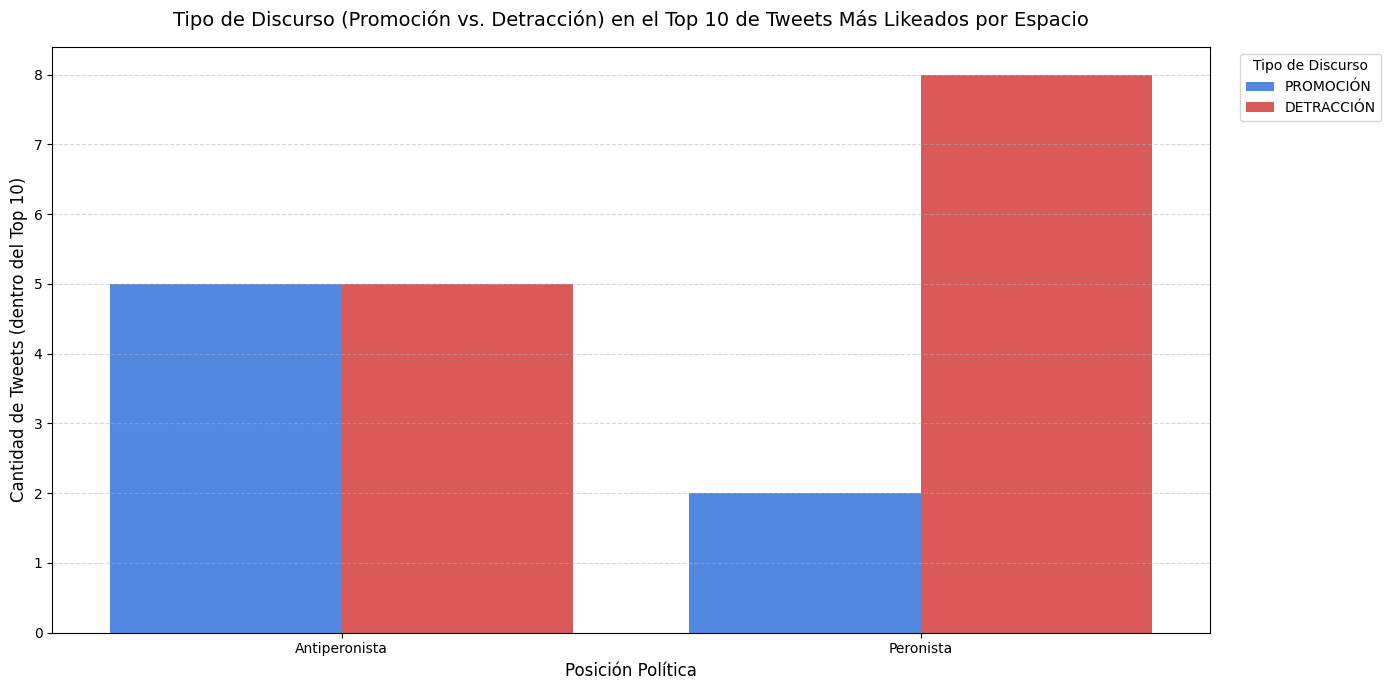

--- Tabla resumen: Emoción y Tipo de Discurso en el Top 10 de más likeados ---


,posición,likes,promoción/apoyo_o_detracción/ataque,emoción_predominante,texto_del_posteo
94,Antiperonista,211000,PROMOCIÓN,FELICIDAD,VIVA LA LIBERTAD CARAJO
101,Antiperonista,198000,DETRACCIÓN,FELICIDAD,El Kirchnerismo llega a su fin.
117,Antiperonista,115000,PROMOCIÓN,FELICIDAD,Felicitaciones Presidente Milei! No le sacaría ni una sola coma a su discurso en el Congreso. No puedo estar más de acuerdo con sus palabras de hoy.
71,Antiperonista,76000,DETRACCIÓN,FURIA,"Te encerraron con una cuarentena récord, te fundieron sin dejarte trabajar, se juntaban en Olivos a tus espaldas, se afanaron las vacunas, llevaron el dólar a $1200, llevaron la inflación a más de un 100% anual y la pobreza a un 50%. Los votaste igual. Te merecés comer mierda."
260,Antiperonista,73000,PROMOCIÓN,FELICIDAD,ES EXACTAMENTE LO QUE VOTEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE (Foto adjunta)
60,Antiperonista,72000,DETRACCIÓN,ASCO,"Hay gente que no llega a fin de mes que votó para Presidente al Ministro de Economía responsable de que no llegue a fin de mes. Argentina, no lo entenderías."
285,Antiperonista,70000,DETRACCIÓN,ENOJO/INDIGNACIÓN,"Mi abuela paterna falleció en tiempos de Cristina, esperando una silla de ruedas que nunca llegó de Pami. Cuando asumió Macri auditaron y encontraron un galpón lleno de esas sillas sin entregar. No me vengan con que les importan los jubilados, manga de forros, nunca le importaron"
291,Antiperonista,68000,DETRACCIÓN,ENOJO/INDIGNACIÓN,Atentaron contra la Casa Rosada utilizando las piedras que recordaban a los fallecidos por la pandemia. Los violentos no tienen el más mínimo respeto por nada. Fin.
116,Antiperonista,65000,PROMOCIÓN,FELICIDAD,"Fin del kirchnerismo\n\nCristina de espalda al pueblo, insultando a los laburantes.\n\nGracias Milei por tanto."
144,Antiperonista,65000,PROMOCIÓN,FELICIDAD,"Algunos miles parando, algunos millones trabajando.\n\nFin."


In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Copiamos y limpiamos el DataFrame
df_vis = df.copy()
df_vis.columns = df_vis.columns.str.strip().str.lower()
df_vis['likes'] = pd.to_numeric(df_vis['likes'], errors='coerce')

# Unificamos variantes de alegría en felicidad por consistencia
if 'emoción_predominante' in df_vis.columns:
    df_vis['emoción_predominante'] = df_vis['emoción_predominante'].replace({
        'ALEGRÍA': 'FELICIDAD',
        'Alegría': 'FELICIDAD',
        'alegría': 'felicidad'
    })

# 2. Filtramos los Top 10 tweets más likeados de cada espacio político
top_10_por_posicion = (
    df_vis.sort_values(['posición', 'likes'], ascending=[True, False])
    .groupby('posición')
    .head(10)
)

# 3. renombramos columnas clave por si tienen nombres largos para los gráficos
col_tipo = 'promoción/apoyo_o_detracción/ataque'
col_emocion = 'emoción_predominante'

# Creamos una tabla cruzada o un conteo para ver qué tipo de discurso predomina en esos Top 10 por posición
tabla_top = pd.crosstab(
    top_10_por_posicion['posición'],
    [top_10_por_posicion[col_tipo], top_10_por_posicion[col_emocion]]
)

# 4. Gráfico de barras para los Top 10
plt.figure(figsize=(14, 7))

# Usamos seaborn para graficar los Top 10 individualmente o en conjunto
# Una excelente forma de ver los 10 de cada uno es con un gráfico de barras apiladas o facetadas:
ax = sns.countplot(
    data=top_10_por_posicion,
    x='posición',
    hue=col_tipo,
    palette=['#3b82f6', '#ef4444', '#10b981', '#f59e0b']
)

plt.title('Tipo de Discurso (Promoción vs. Detracción) en el Top 10 de Tweets Más Likeados por Espacio', fontsize=14, pad=15)
plt.xlabel('Posición Política', fontsize=12)
plt.ylabel('Cantidad de Tweets (dentro del Top 10)', fontsize=12)
plt.legend(title='Tipo de Discurso', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Opcional: Mostrar también la tabla resumen en consola para ver las emociones exactas de esos Top 10
print("--- Tabla resumen: Emoción y Tipo de Discurso en el Top 10 de más likeados ---")
resumen_top = top_10_por_posicion[['posición', 'likes', col_tipo, col_emocion, 'texto_del_posteo' if 'texto_del_posteo' in top_10_por_posicion.columns else 'texto']]
display(resumen_top)

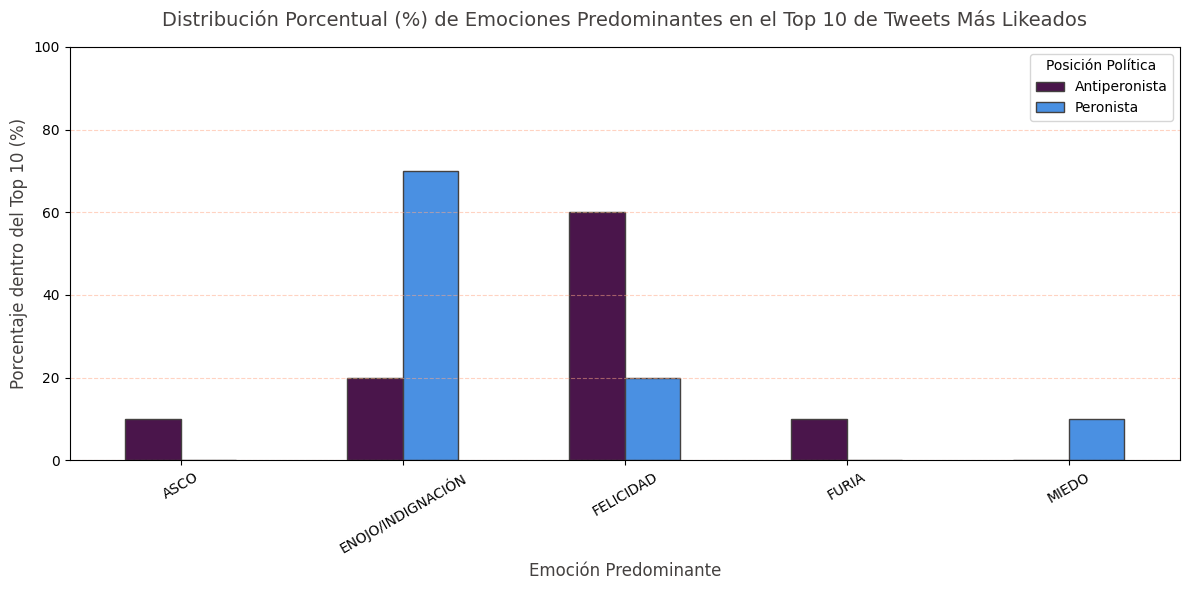

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Copiamos y limpiamos el DataFrame
df_vis = df.copy()
df_vis.columns = df_vis.columns.str.strip().str.lower()
df_vis['likes'] = pd.to_numeric(df_vis['likes'], errors='coerce')

# Unificamos variantes de alegría en felicidad
if 'emoción_predominante' in df_vis.columns:
    df_vis['emoción_predominante'] = df_vis['emoción_predominante'].replace({
        'ALEGRÍA': 'FELICIDAD',
        'Alegría': 'FELICIDAD',
        'alegría': 'felicidad'
    })

# 2. Filtramos los Top 10 tweets más likeados de cada espacio político
top_10_por_posicion = (
    df_vis.sort_values(['posición', 'likes'], ascending=[True, False])
    .groupby('posición')
    .head(10)
)

col_emocion = 'emoción_predominante'

# 3. Creamos la tabla cruzada en porcentajes (normalizada por cada posición) para las emociones
tabla_porcentual_emociones = pd.crosstab(
    top_10_por_posicion[col_emocion],
    top_10_por_posicion['posición'],
    normalize='columns'
) * 100

# 4. Definimos los colores característicos para cada bloque político
# (Ajustá el orden si tu tabla alfabéticamente toma primero otro grupo: ej. antiperonista / peronista)
colores_bloques = ['#4a154b', '#4a90e2']

# 5. Gráfico de barras porcentual (0 a 100%) con colores definidos
ax = tabla_porcentual_emociones.plot(
    kind='bar',
    figsize=(12, 6),
    color=colores_bloques,
    edgecolor='#444140',
    linewidth=1,
    rot=30
)

plt.title('Distribución Porcentual (%) de Emociones Predominantes en el Top 10 de Tweets Más Likeados', fontsize=14, color='#444140', pad=15)
plt.xlabel('Emoción Predominante', fontsize=12, color='#444140')
plt.ylabel('Porcentaje dentro del Top 10 (%)', fontsize=12, color='#444140')
plt.ylim(0, 100)
plt.legend(title='Posición Política', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

## Evolucion del uso de lenguaje populista y estereotipos negativos

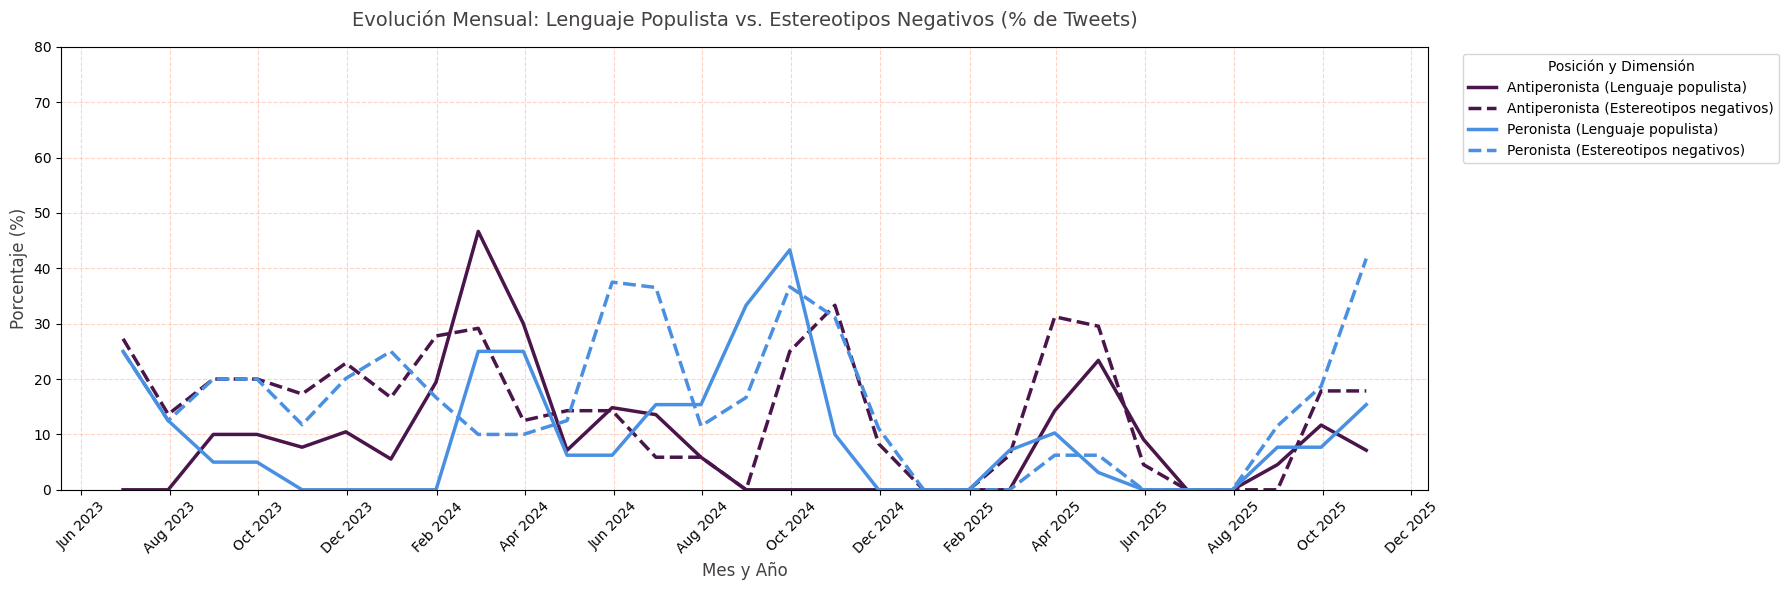

In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Copia y preparación de datos utilizando 'df'
df_plot = df.copy().reset_index()
df_plot["fecha"] = pd.to_datetime(df_plot["fecha"])
df_plot = df_plot.set_index("fecha")

# Definimos los colores para cada posición política
colores_posicion = {
    'peronista': '#4a90e2',      # Celeste
    'antiperonista': '#4a154b'   # Morado oscuro
}

# Definimos los estilos de línea para las dos variables elegidas
estilos_variables = {
    'uso_de_lenguaje_populista': '-',            # Línea sólida
    'repite_estereotipos_negativos': '--' # Línea discontinua (dashed)
}

# Nombres más limpios para la leyenda
nombres_legibles = {
    'uso_de_lenguaje_populista': 'Lenguaje populista',
    'repite_estereotipos_negativos': 'Estereotipos negativos'
}

# Aumentamos el ancho de la figura a 18 para que no se comprima
plt.figure(figsize=(18, 6))

# Iteramos por posición política y por cada una de las dos variables
for posicion, grupo in df_plot.groupby('posición'):
    df_monthly = grupo.resample('ME').mean(numeric_only=True).fillna(0) * 100
    df_smooth = df_monthly.rolling(window=2, min_periods=1).mean()

    color_base = colores_posicion.get(str(posicion).lower(), '#333333')

    for var, estilo in estilos_variables.items():
        if var in df_smooth.columns:
            etiqueta = f"{str(posicion).capitalize()} ({nombres_legibles[var]})"

            plt.plot(
                df_smooth.index,
                df_smooth[var],
                linestyle=estilo,
                linewidth=2.5,
                color=color_base,
                label=etiqueta
            )

plt.title('Evolución Mensual: Lenguaje Populista vs. Estereotipos Negativos (% de Tweets)', fontsize=14, color='#444140', pad=15)
plt.xlabel('Mes y Año', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.ylim(0, 80)
# Mejoramos las marcas del eje X
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Ubicamos la leyenda a un costado
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Posición y Dimensión')
plt.grid(True, linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

## Estereotipos negativos: lenguaje populista y palabras malsonantes

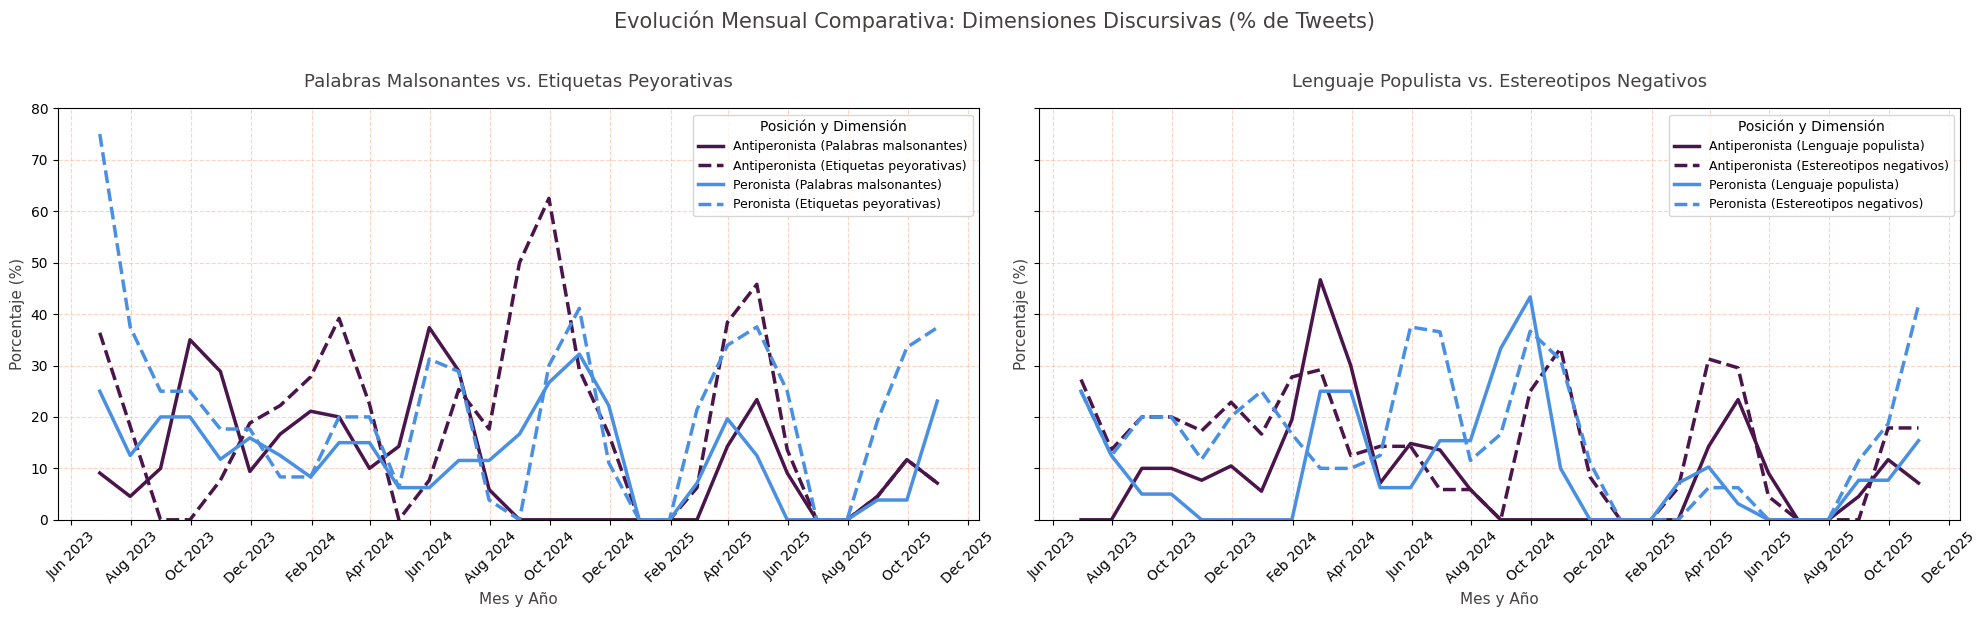

In [60]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Copia y preparación de datos utilizando 'df'
df_plot = df.copy().reset_index()
df_plot["fecha"] = pd.to_datetime(df_plot["fecha"])
df_plot = df_plot.set_index("fecha")

# Definimos los colores para cada posición política
colores_posicion = {
    'peronista': '#4a90e2',      # Celeste
    'antiperonista': '#4a154b'   # Morado oscuro
}

# Creamos la figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# ==========================================
# GRÁFICO 1: Palabras Malsonantes vs. Etiquetas Peyorativas
# ==========================================
estilos_vars_1 = {
    'uso_de_palabras_malsonantes': '-',          # Línea sólida
    'uso_de_etiquetas_peyorativas': '--'         # Línea discontinua
}
nombres_leg_1 = {
    'uso_de_palabras_malsonantes': 'Palabras malsonantes',
    'uso_de_etiquetas_peyorativas': 'Etiquetas peyorativas'
}

for posicion, grupo in df_plot.groupby('posición'):
    df_monthly = grupo.resample('ME').mean(numeric_only=True).fillna(0) * 100
    df_smooth = df_monthly.rolling(window=2, min_periods=1).mean()
    color_base = colores_posicion.get(str(posicion).lower(), '#333333')

    for var, estilo in estilos_vars_1.items():
        if var in df_smooth.columns:
            etiqueta = f"{str(posicion).capitalize()} ({nombres_leg_1[var]})"
            ax1.plot(
                df_smooth.index, df_smooth[var],
                linestyle=estilo, linewidth=2.5, color=color_base, label=etiqueta
            )

ax1.set_title('Palabras Malsonantes vs. Etiquetas Peyorativas', fontsize=13, color='#444140', pad=15)
ax1.set_xlabel('Mes y Año', fontsize=11, color='#444140')
ax1.set_ylabel('Porcentaje (%)', fontsize=11, color='#444140')
ax1.set_ylim(0, 80)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper right', fontsize=9, title='Posición y Dimensión')
ax1.grid(True, linestyle='--', alpha=0.5, color='#ffa987')


# ==========================================
# GRÁFICO 2: Lenguaje Populista vs. Estereotipos Negativos
# ==========================================
estilos_vars_2 = {
    'uso_de_lenguaje_populista': '-',            # Línea sólida
    'repite_estereotipos_negativos': '--'        # Línea discontinua
}
nombres_leg_2 = {
    'uso_de_lenguaje_populista': 'Lenguaje populista',
    'repite_estereotipos_negativos': 'Estereotipos negativos'
}

for posicion, grupo in df_plot.groupby('posición'):
    df_monthly = grupo.resample('ME').mean(numeric_only=True).fillna(0) * 100
    df_smooth = df_monthly.rolling(window=2, min_periods=1).mean()
    color_base = colores_posicion.get(str(posicion).lower(), '#333333')

    for var, estilo in estilos_vars_2.items():
        if var in df_smooth.columns:
            etiqueta = f"{str(posicion).capitalize()} ({nombres_leg_2[var]})"
            ax2.plot(
                df_smooth.index, df_smooth[var],
                linestyle=estilo, linewidth=2.5, color=color_base, label=etiqueta
            )

ax2.set_title('Lenguaje Populista vs. Estereotipos Negativos', fontsize=13, color='#444140', pad=15)
ax2.set_xlabel('Mes y Año', fontsize=11, color='#444140')
ax2.set_ylabel('Porcentaje (%)', fontsize=11, color='#444140')
ax2.set_ylim(0, 80)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper right', fontsize=9, title='Posición y Dimensión')
ax2.grid(True, linestyle='--', alpha=0.5, color='#ffa987')

# Ajustes generales de la figura
fig.suptitle('Evolución Mensual Comparativa: Dimensiones Discursivas (% de Tweets)', fontsize=15, color='#444140', y=1.02)
plt.tight_layout()
plt.show()

## Evolución uso repetición de estereotipos negativos y palabras malsonantes

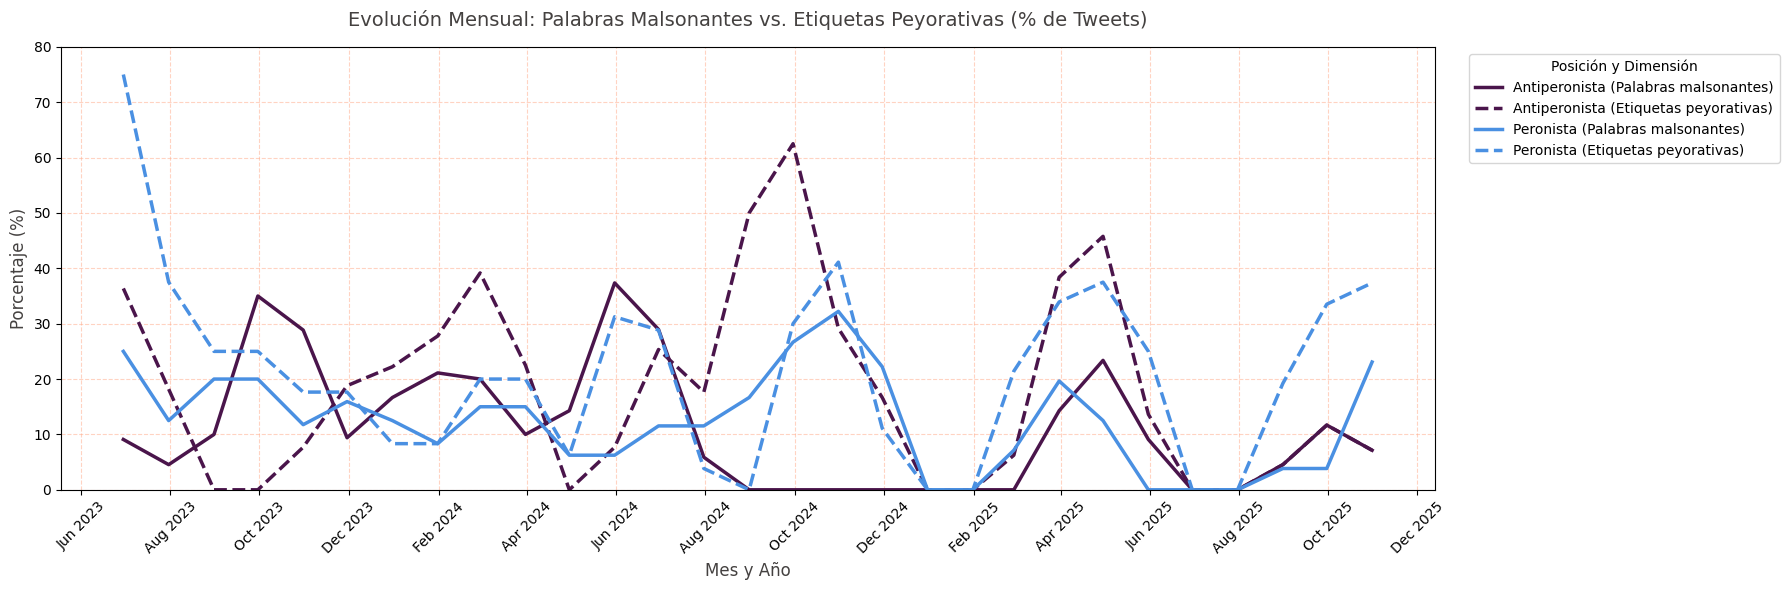

In [42]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Copia y preparación de datos utilizando 'df'
df_plot = df.copy().reset_index()
df_plot["fecha"] = pd.to_datetime(df_plot["fecha"])
df_plot = df_plot.set_index("fecha")

# Definimos los colores para cada posición política
colores_posicion = {
    'peronista': '#4a90e2',      # Celeste
    'antiperonista': '#4a154b'   # Morado oscuro
}

# Definimos los estilos de línea para las dos variables elegidas
estilos_variables = {
    'uso_de_palabras_malsonantes': '-',          # Línea sólida
    'uso_de_etiquetas_peyorativas': '--'         # Línea discontinua (dashed)
}

# Nombres más limpios para la leyenda
nombres_legibles = {
    'uso_de_palabras_malsonantes': 'Palabras malsonantes',
    'uso_de_etiquetas_peyorativas': 'Etiquetas peyorativas'
}

# Aumentamos el ancho de la figura a 18 para que no se comprima
plt.figure(figsize=(18, 6))

# Iteramos por posición política y por cada una de las dos variables
for posicion, grupo in df_plot.groupby('posición'):
    df_monthly = grupo.resample('ME').mean(numeric_only=True).fillna(0) * 100
    df_smooth = df_monthly.rolling(window=2, min_periods=1).mean()

    color_base = colores_posicion.get(str(posicion).lower(), '#333333')

    for var, estilo in estilos_variables.items():
        if var in df_smooth.columns:
            etiqueta = f"{str(posicion).capitalize()} ({nombres_legibles[var]})"

            plt.plot(
                df_smooth.index,
                df_smooth[var],
                linestyle=estilo,
                linewidth=2.5,
                color=color_base,
                label=etiqueta
            )

plt.title('Evolución Mensual: Palabras Malsonantes vs. Etiquetas Peyorativas (% de Tweets)', fontsize=14, color='#444140', pad=15)
plt.xlabel('Mes y Año', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.ylim(0, 80)

# Mejoramos las marcas del eje X para que muestren los meses/años de forma limpia
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Muestra una marca cada 2 meses (ajustá a 1 o 3 si querés)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Ubicamos la leyenda a un costado
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Posición y Dimensión')
plt.grid(True, linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

## Evolución del uso de la ironía y el humor

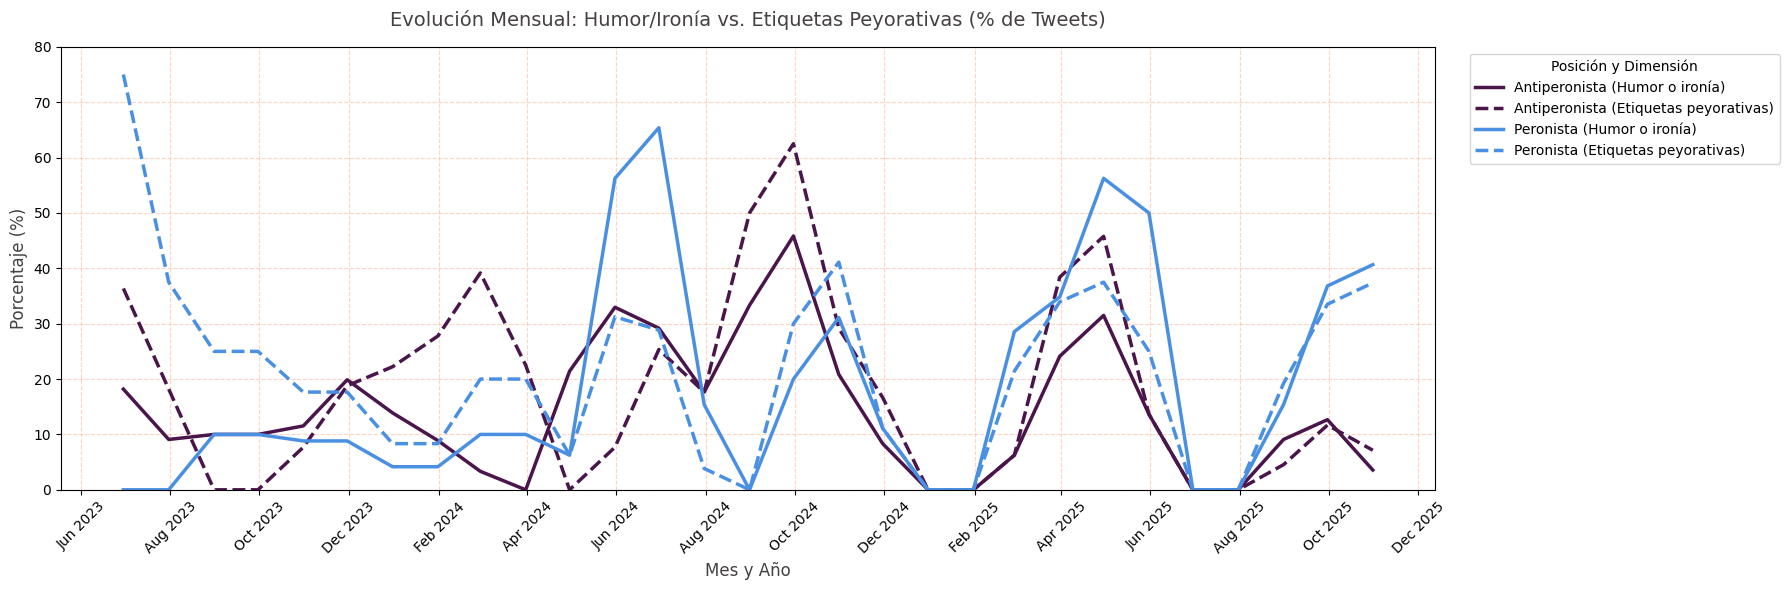

In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Copia y preparación de datos utilizando 'df'
df_plot = df.copy().reset_index()
df_plot["fecha"] = pd.to_datetime(df_plot["fecha"])
df_plot = df_plot.set_index("fecha")

# Definimos los colores para cada posición política
colores_posicion = {
    'peronista': '#4a90e2',      # Celeste
    'antiperonista': '#4a154b'   # Morado oscuro
}

# Definimos los estilos de línea para las variables (incluyendo el humor/ironía)
estilos_variables = {
    'uso_del_humor_o_ironía': '-',          # Línea sólida
    'uso_de_etiquetas_peyorativas': '--'    # Línea discontinua (dashed)
}

# Nombres más limpios para la leyenda
nombres_legibles = {
    'uso_del_humor_o_ironía': 'Humor o ironía',
    'uso_de_etiquetas_peyorativas': 'Etiquetas peyorativas'
}

# Aumentamos el ancho de la figura a 18 para que no se comprima
plt.figure(figsize=(18, 6))

# Iteramos por posición política y por cada una de las dos variables
for posicion, grupo in df_plot.groupby('posición'):
    df_monthly = grupo.resample('ME').mean(numeric_only=True).fillna(0) * 100
    df_smooth = df_monthly.rolling(window=2, min_periods=1).mean()

    color_base = colores_posicion.get(str(posicion).lower(), '#333333')

    for var, estilo in estilos_variables.items():
        if var in df_smooth.columns:
            etiqueta = f"{str(posicion).capitalize()} ({nombres_legibles[var]})"

            plt.plot(
                df_smooth.index,
                df_smooth[var],
                linestyle=estilo,
                linewidth=2.5,
                color=color_base,
                label=etiqueta
            )

plt.title('Evolución Mensual: Humor/Ironía vs. Etiquetas Peyorativas (% de Tweets)', fontsize=14, color='#444140', pad=15)
plt.xlabel('Mes y Año', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.ylim(0, 80)
# Mejoramos las marcas del eje X para que muestren los meses/años de forma limpia
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Muestra una marca cada 2 meses
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Ubicamos la leyenda a un costado
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Posición y Dimensión')
plt.grid(True, linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

## Palabras malsonantes y uso del humor

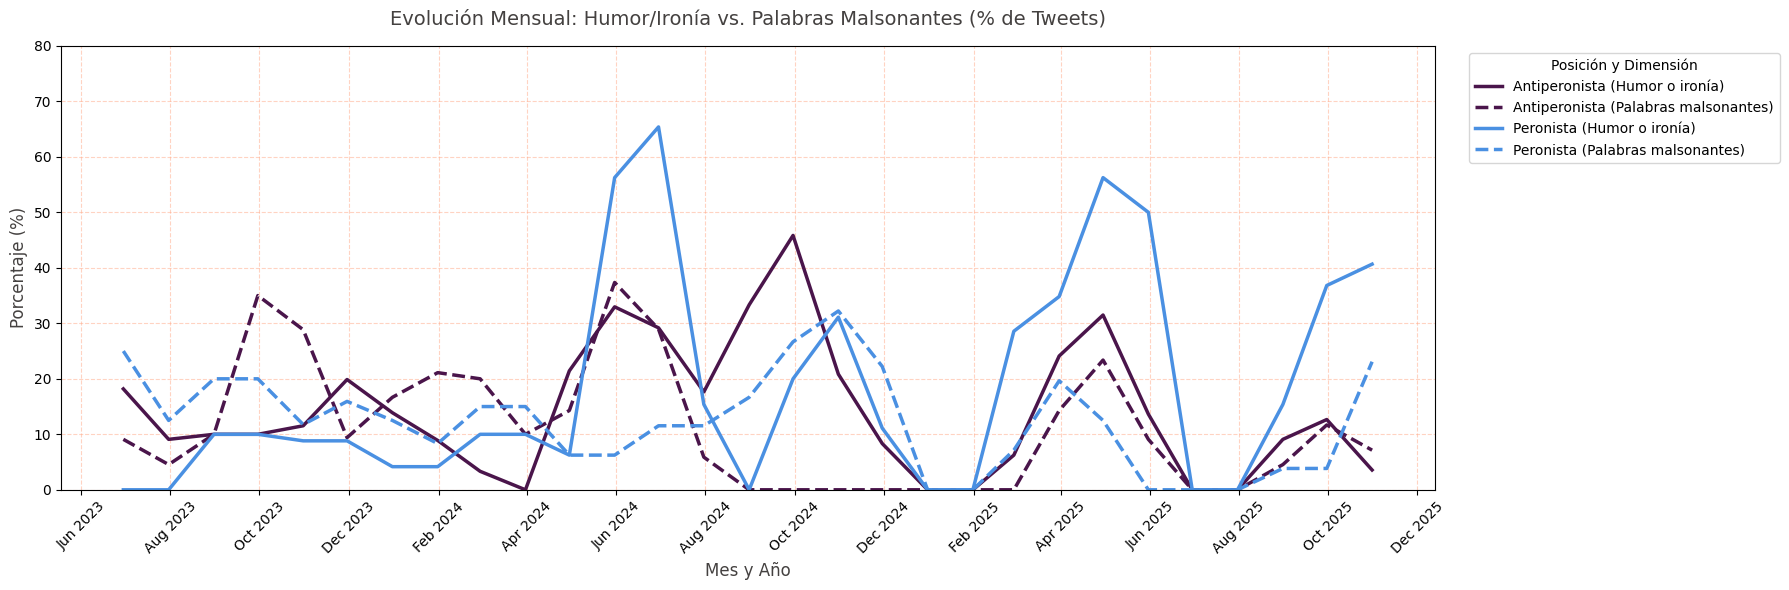

In [44]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Copia y preparación de datos utilizando 'df'
df_plot = df.copy().reset_index()
df_plot["fecha"] = pd.to_datetime(df_plot["fecha"])
df_plot = df_plot.set_index("fecha")

# Definimos los colores para cada posición política
colores_posicion = {
    'peronista': '#4a90e2',      # Celeste
    'antiperonista': '#4a154b'   # Morado oscuro
}

# Definimos los estilos de línea para las variables solicitadas
estilos_variables = {
    'uso_del_humor_o_ironía': '-',          # Línea sólida
    'uso_de_palabras_malsonantes': '--'     # Línea discontinua (dashed)
}

# Nombres más limpios para la leyenda
nombres_legibles = {
    'uso_del_humor_o_ironía': 'Humor o ironía',
    'uso_de_palabras_malsonantes': 'Palabras malsonantes'
}

# Aumentamos el ancho de la figura a 18 para que no se comprima
plt.figure(figsize=(18, 6))

# Iteramos por posición política y por cada una de las dos variables
for posicion, grupo in df_plot.groupby('posición'):
    df_monthly = grupo.resample('ME').mean(numeric_only=True).fillna(0) * 100
    df_smooth = df_monthly.rolling(window=2, min_periods=1).mean()

    color_base = colores_posicion.get(str(posicion).lower(), '#333333')

    for var, estilo in estilos_variables.items():
        if var in df_smooth.columns:
            etiqueta = f"{str(posicion).capitalize()} ({nombres_legibles[var]})"

            plt.plot(
                df_smooth.index,
                df_smooth[var],
                linestyle=estilo,
                linewidth=2.5,
                color=color_base,
                label=etiqueta
            )

plt.title('Evolución Mensual: Humor/Ironía vs. Palabras Malsonantes (% de Tweets)', fontsize=14, color='#444140', pad=15)
plt.xlabel('Mes y Año', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.ylim(0, 80)

# Mejoramos las marcas del eje X para que muestren los meses/años de forma limpia
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Muestra una marca cada 2 meses
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Ubicamos la leyenda a un costado
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Posición y Dimensión')
plt.grid(True, linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

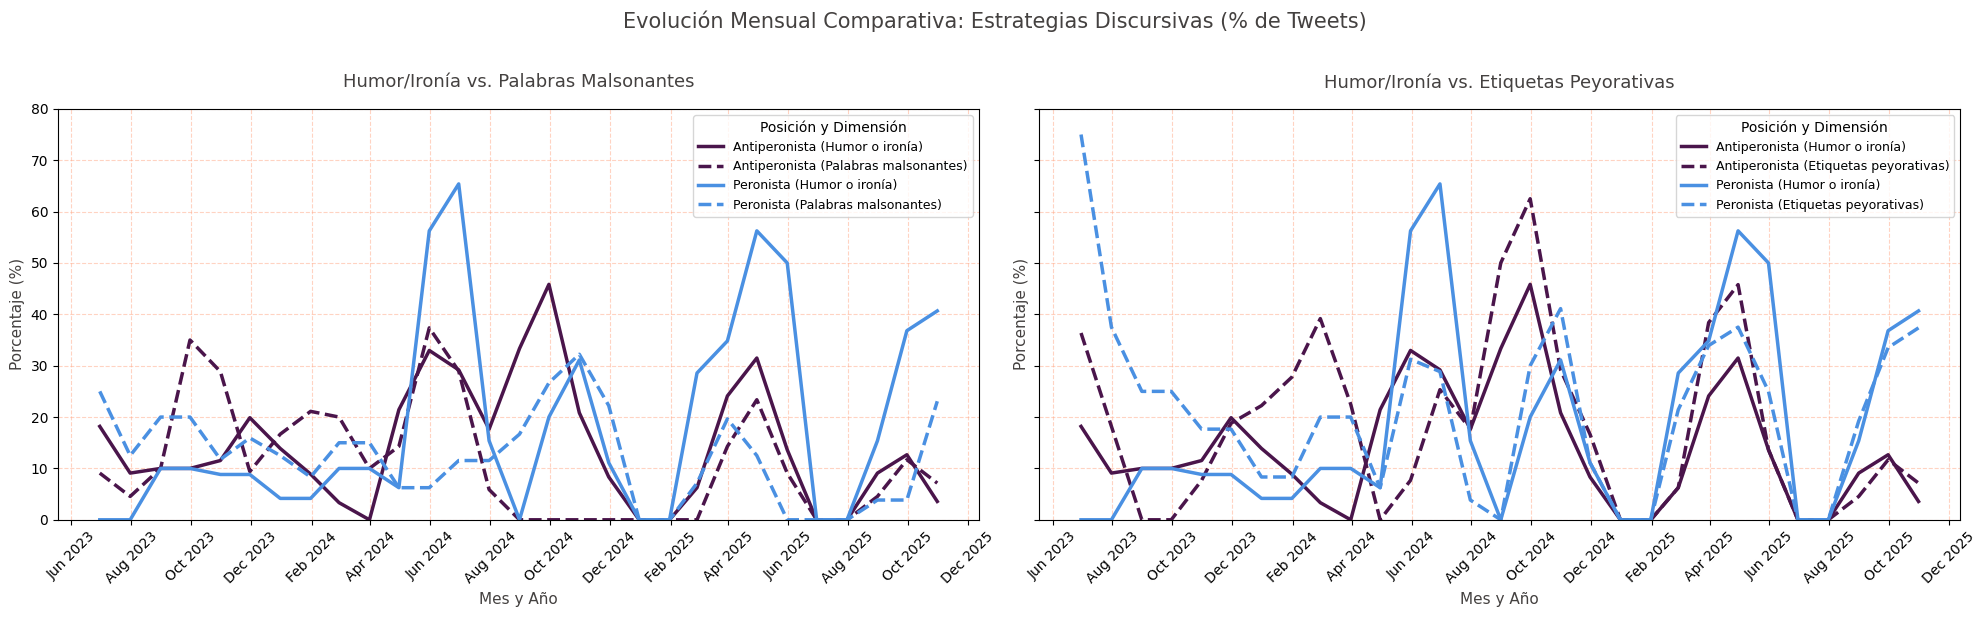

In [59]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Copia y preparación de datos utilizando 'df'
df_plot = df.copy().reset_index()
df_plot["fecha"] = pd.to_datetime(df_plot["fecha"])
df_plot = df_plot.set_index("fecha")

# Definimos los colores para cada posición política
colores_posicion = {
    'peronista': '#4a90e2',      # Celeste
    'antiperonista': '#4a154b'   # Morado oscuro
}

# Creamos la figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# ==========================================
# GRÁFICO 1: Humor/Ironía vs. Palabras Malsonantes
# ==========================================
estilos_vars_1 = {
    'uso_del_humor_o_ironía': '-',         # Línea sólida
    'uso_de_palabras_malsonantes': '--'    # Línea discontinua
}
nombres_leg_1 = {
    'uso_del_humor_o_ironía': 'Humor o ironía',
    'uso_de_palabras_malsonantes': 'Palabras malsonantes'
}

for posicion, grupo in df_plot.groupby('posición'):
    df_monthly = grupo.resample('ME').mean(numeric_only=True).fillna(0) * 100
    df_smooth = df_monthly.rolling(window=2, min_periods=1).mean()
    color_base = colores_posicion.get(str(posicion).lower(), '#333333')

    for var, estilo in estilos_vars_1.items():
        if var in df_smooth.columns:
            etiqueta = f"{str(posicion).capitalize()} ({nombres_leg_1[var]})"
            ax1.plot(
                df_smooth.index, df_smooth[var],
                linestyle=estilo, linewidth=2.5, color=color_base, label=etiqueta
            )

ax1.set_title('Humor/Ironía vs. Palabras Malsonantes', fontsize=13, color='#444140', pad=15)
ax1.set_xlabel('Mes y Año', fontsize=11, color='#444140')
ax1.set_ylabel('Porcentaje (%)', fontsize=11, color='#444140')
ax1.set_ylim(0, 80)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper right', fontsize=9, title='Posición y Dimensión')
ax1.grid(True, linestyle='--', alpha=0.5, color='#ffa987')


# ==========================================
# GRÁFICO 2: Humor/Ironía vs. Etiquetas Peyorativas
# ==========================================
estilos_vars_2 = {
    'uso_del_humor_o_ironía': '-',         # Línea sólida
    'uso_de_etiquetas_peyorativas': '--'   # Línea discontinua
}
nombres_leg_2 = {
    'uso_del_humor_o_ironía': 'Humor o ironía',
    'uso_de_etiquetas_peyorativas': 'Etiquetas peyorativas'
}

for posicion, grupo in df_plot.groupby('posición'):
    df_monthly = grupo.resample('ME').mean(numeric_only=True).fillna(0) * 100
    df_smooth = df_monthly.rolling(window=2, min_periods=1).mean()
    color_base = colores_posicion.get(str(posicion).lower(), '#333333')

    for var, estilo in estilos_vars_2.items():
        if var in df_smooth.columns:
            etiqueta = f"{str(posicion).capitalize()} ({nombres_leg_2[var]})"
            ax2.plot(
                df_smooth.index, df_smooth[var],
                linestyle=estilo, linewidth=2.5, color=color_base, label=etiqueta
            )

ax2.set_title('Humor/Ironía vs. Etiquetas Peyorativas', fontsize=13, color='#444140', pad=15)
ax2.set_xlabel('Mes y Año', fontsize=11, color='#444140')
ax2.set_ylabel('Porcentaje (%)', fontsize=11, color='#444140')
ax2.set_ylim(0, 80)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper right', fontsize=9, title='Posición y Dimensión')
ax2.grid(True, linestyle='--', alpha=0.5, color='#ffa987')

# Ajustes generales de la figura
fig.suptitle('Evolución Mensual Comparativa: Estrategias Discursivas (% de Tweets)', fontsize=15, color='#444140', y=1.02)
plt.tight_layout()
plt.show()

## Tipo de microargumentación

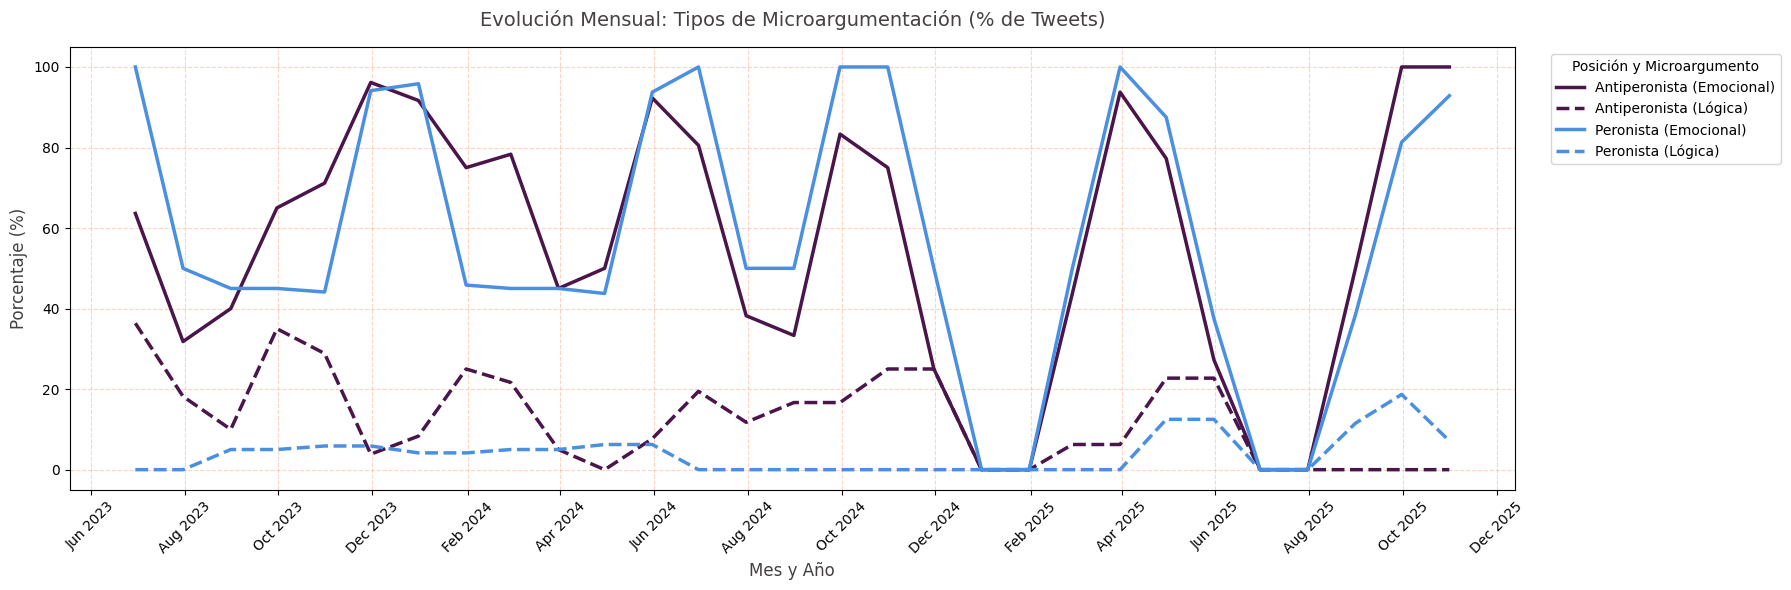

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Copia y preparación robusta de datos
df_plot = df.copy().reset_index()
df_plot["fecha"] = pd.to_datetime(df_plot["fecha"], errors='coerce')
df_plot = df_plot.dropna(subset=['fecha'])

# Nos aseguramos de que la columna de posición y la de microargumentación existan y estén limpias
df_plot['posición'] = df_plot['posición'].astype(str).str.lower()
df_plot['tipo_de_microargumentación'] = df_plot['tipo_de_microargumentación'].astype(str)

# 2. Convertimos la variable categórica de microargumentación en columnas dummy (one-hot encoding)
# Esto nos permite calcular el porcentaje de aparición de cada tipo de argumento por mes
df_dummies = pd.get_dummies(df_plot, columns=['tipo_de_microargumentación'], prefix='arg')

# Volvemos a asignar la fecha como índice en el nuevo dataframe con dummies
df_dummies['fecha'] = df_plot['fecha']
df_dummies = df_dummies.set_index("fecha")

# Definimos los colores para cada posición política
colores_posicion = {
    'peronista': '#4a90e2',      # Celeste
    'antiperonista': '#4a154b'   # Morado oscuro
}

# Estilos de línea según el tipo de microargumentación detectado
# (Se asignan automáticamente según las categorías que salgan del get_dummies)
estilos_disponibles = ['-', '--', '-.', ':']

plt.figure(figsize=(18, 6))

# Agrupamos por posición política y mes, calculando la media (porcentaje) de las columnas dummy
for posicion, grupo in df_dummies.groupby('posición'):
    # Seleccionamos solo las columnas de argumentos generadas
    cols_arg = [c for c in grupo.columns if c.startswith('arg_')]

    # Resample mensual de las columnas de argumentos
    df_monthly = grupo[cols_arg].resample('ME').mean().fillna(0) * 100
    df_smooth = df_monthly.rolling(window=2, min_periods=1).mean()

    color_base = colores_posicion.get(posicion, '#333333')

    for i, col in enumerate(cols_arg):
        nombre_arg = col.replace('arg_', '').capitalize()
        estilo = estilos_disponibles[i % len(estilos_disponibles)]
        etiqueta = f"{posicion.capitalize()} ({nombre_arg})"

        plt.plot(
            df_smooth.index,
            df_smooth[col],
            linestyle=estilo,
            linewidth=2.5,
            color=color_base,
            label=etiqueta
        )

plt.title('Evolución Mensual: Tipos de Microargumentación (% de Tweets)', fontsize=14, color='#444140', pad=15)
plt.xlabel('Mes y Año', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')

# Mejoramos las marcas del eje X
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Ubicamos la leyenda a un costado para que no tape las líneas
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Posición y Microargumento')
plt.grid(True, linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

## Emociones en total

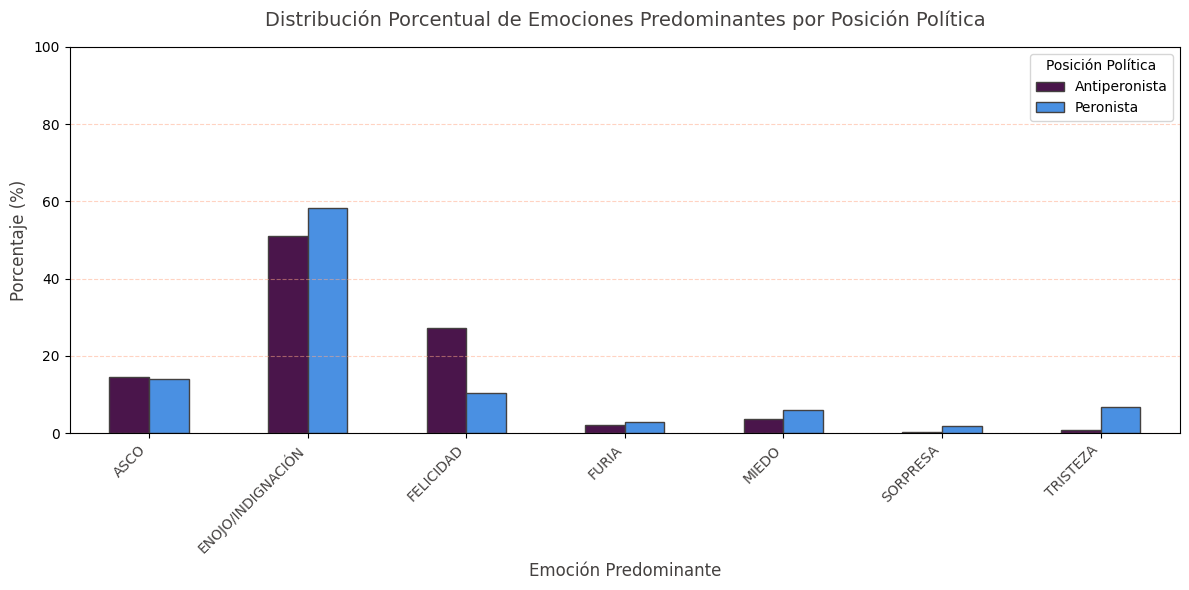

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# Copia de tu dataframe principal y unificación de Alegría/Felicidad
df_plot = df.copy()
if 'emoción_predominante' in df_plot.columns:
    df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
        'ALEGRÍA': 'FELICIDAD',
        'Alegría': 'FELICIDAD',
        'alegría': 'felicidad'
    })

# Tabla cruzada normalizada por filas (porcentaje respecto al total de cada posición política)
tabla_emociones_pct = pd.crosstab(
    df_plot['emoción_predominante'],
    df_plot['posición'],
    normalize='columns'
) * 100

# Definimos la lista de colores para las barras
colores_barras = ['#4a154b', '#4a90e2'] # Ajustá el orden si tus categorías de 'posición' difieren

ax = tabla_emociones_pct.plot(
    kind='bar',
    figsize=(12, 6),
    color=colores_barras,
    edgecolor='#444140',
    linewidth=1,
    grid=False
)

plt.title('Distribución Porcentual de Emociones Predominantes por Posición Política', fontsize=14, color='#444140', pad=15)
plt.xlabel('Emoción Predominante', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right', color='#444140')
plt.legend(title='Posición Política')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

## Distribucion por tipo de microargumentación

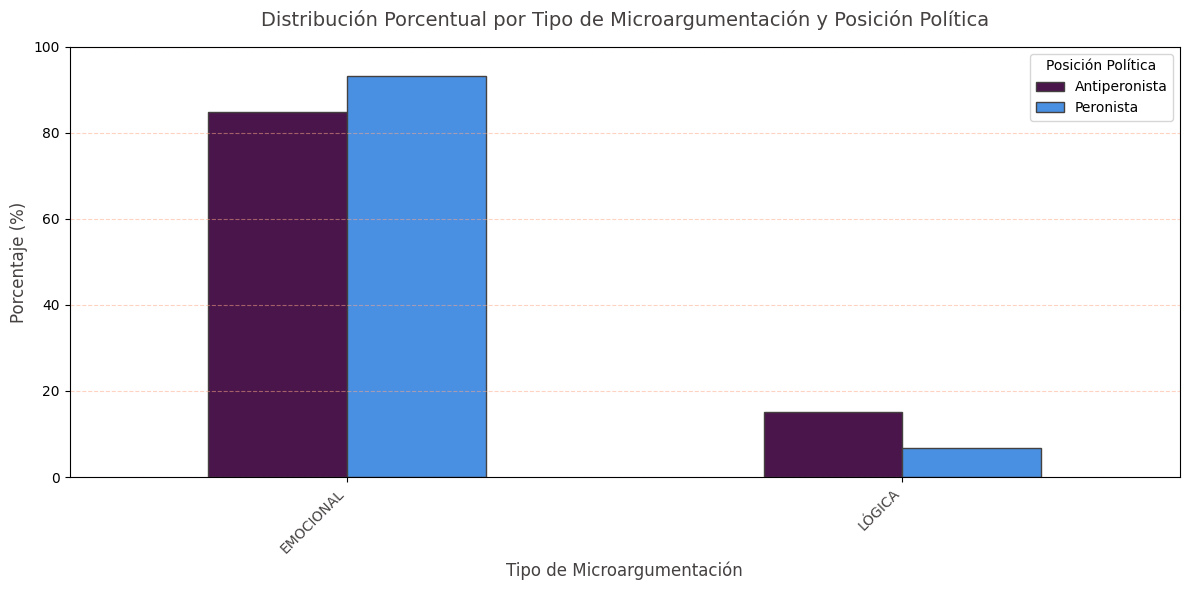

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

# Copia del DataFrame df
df_plot = df.copy()

# Tabla cruzada para calcular porcentajes por tipo de microargumentación y posición política
# (Asegurate de que los nombres de las columnas 'tipo_microargumentacion' y 'posición' coincidan con los de tu DataFrame)
tabla_argumentos = pd.crosstab(
    df_plot['tipo_de_microargumentación'],
    df_plot['posición'],
    normalize='columns'
) * 100

# Definimos la lista de colores para las barras
colores_barras = ['#4a154b', '#4a90e2'] # Ajusta el orden según corresponda a antiperonista/peronista

ax = tabla_argumentos.plot(
    kind='bar',
    figsize=(12, 6),
    color=colores_barras,
    edgecolor='#444140',
    linewidth=1
)

plt.title('Distribución Porcentual por Tipo de Microargumentación y Posición Política', fontsize=14, color='#444140', pad=15)
plt.xlabel('Tipo de Microargumentación', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right', color='#444140')
plt.legend(title='Posición Política')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

# **Campaña 2023**

## Emociones durante la campaña

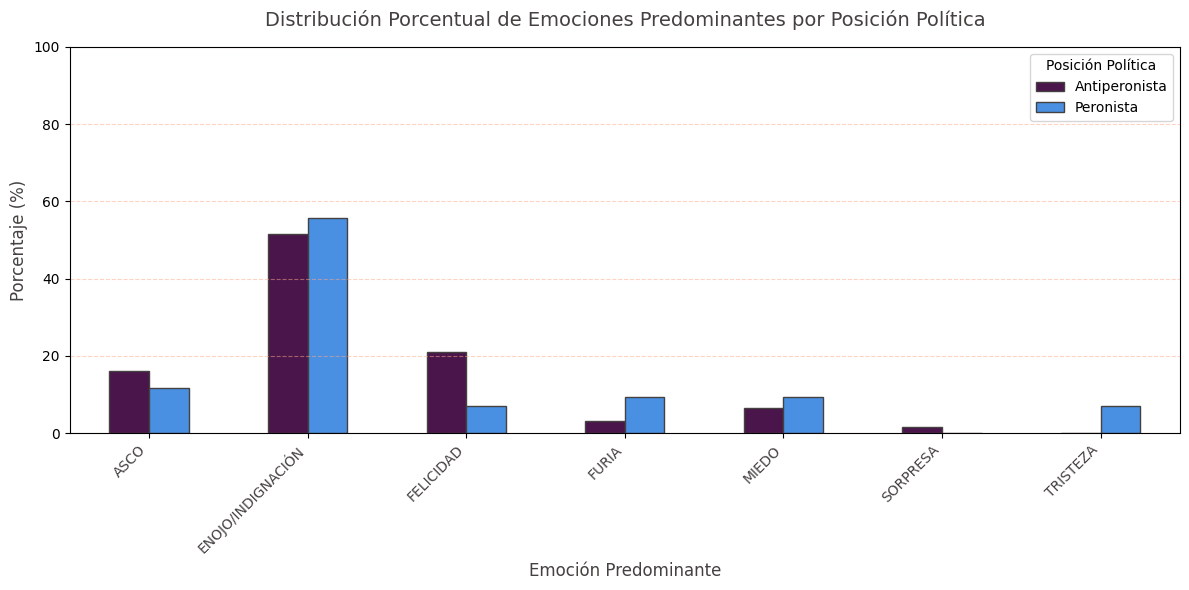

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# Copia y unificación de Alegría en Felicidad
df_campana_2023_plot = df_campana_2023.copy() # O podés usar df_campana_2023_campana_2023 si así se llama tu dataframe específico
if 'emoción_predominante' in df_campana_2023_plot.columns:
    df_campana_2023_plot['emoción_predominante'] = df_campana_2023_plot['emoción_predominante'].replace({
        'ALEGRÍA': 'FELICIDAD',
        'Alegría': 'FELICIDAD',
        'alegría': 'felicidad'
    })

# Tabla cruzada normalizada en porcentaje por posición política
tabla_emociones = pd.crosstab(
    df_campana_2023_plot['emoción_predominante'],
    df_campana_2023_plot['posición'],
    normalize='columns'
) * 100

# Definimos la lista de colores para las barras en el mismo orden de las columnas de la tabla
colores_barras = ['#4a154b', '#4a90e2'] # Ajusta el orden según corresponda a antiperonista/peronista

ax = tabla_emociones.plot(
    kind='bar',
    figsize=(12, 6),
    color=colores_barras,
    edgecolor='#444140',
    linewidth=1,
    grid=False
)

plt.title('Distribución Porcentual de Emociones Predominantes por Posición Política', fontsize=14, color='#444140', pad=15)
plt.xlabel('Emoción Predominante', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right', color='#444140')
plt.legend(title='Posición Política')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

In [7]:
# 1. Veamos qué valores tiene exactamente la columna ahora mismo
col_objetivo = 'promoción/apoyo_o_detracción/ataque'
print("Valores únicos antes de limpiar:", df_campana_2023[col_objetivo].unique())

# 2. Limpieza robusta usando reemplazo basado en minúsculas y sin acentos de referencia
df_campana_2023[col_objetivo] = df_campana_2023[col_objetivo].astype(str).str.strip().str.lower()

# Forzamos los reemplazos principales
remplazos = {
    'promocion': 'promoción',
    'promoción/apoyo': 'promoción', # por si acaso agrupa todo ahí
    'detraccion': 'detracción',
    'ataque': 'detracción' # si querés unificar ataque con detracción, o dejalos como están
}
df_campana_2023[col_objetivo] = df_campana_2023[col_objetivo].replace(remplazos)

print("Valores únicos después de limpiar:", df_campana_2023[col_objetivo].unique())

Valores únicos antes de limpiar: ['DETRACCIÓN' 'PROMOCIÓN' 'PROMOCION']
Valores únicos después de limpiar: ['detracción' 'promoción']


/tmp/ipykernel_2466/2639581504.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_campana_2023[col_objetivo] = df_campana_2023[col_objetivo].astype(str).str.strip().str.lower()
/tmp/ipykernel_2466/2639581504.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_campana_2023[col_objetivo] = df_campana_2023[col_objetivo].replace(remplazos)


## Promoción y detracción por posición 2023

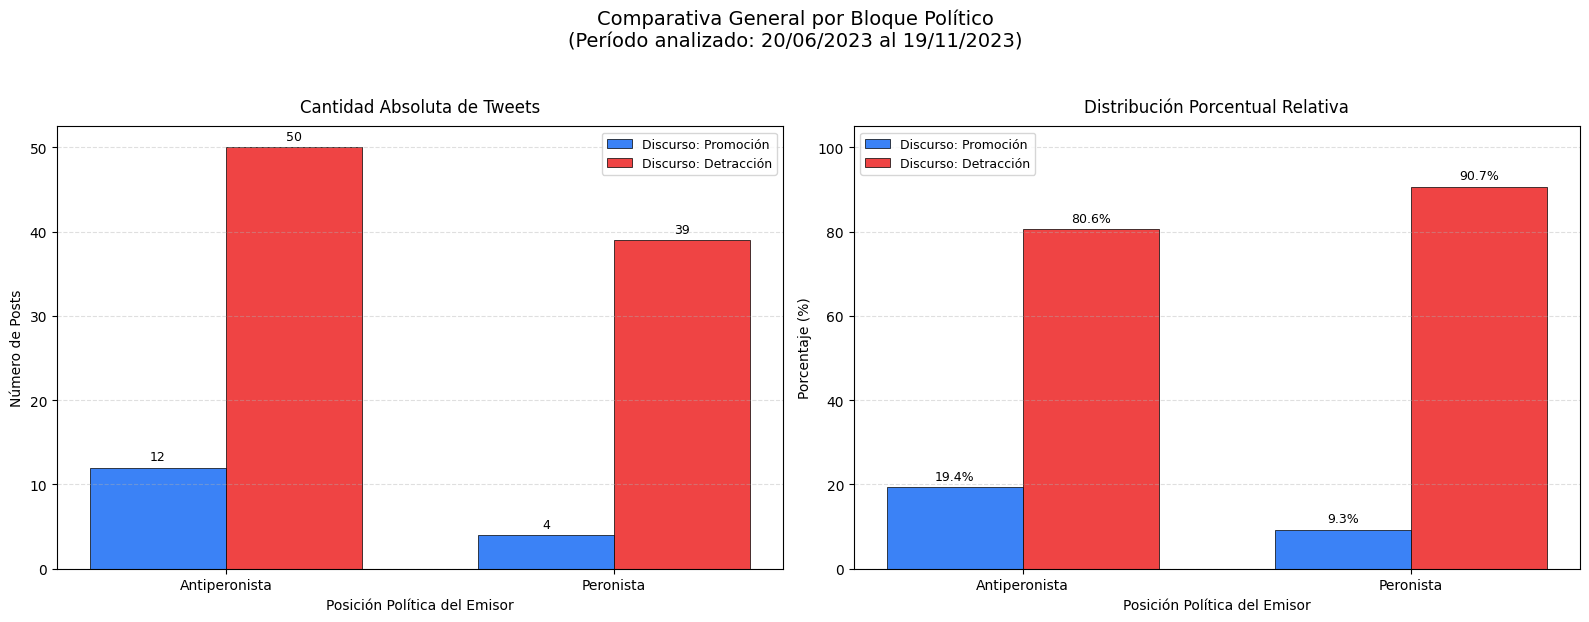

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Copia y preparación del DataFrame limpio
df_plot = df_campana_2023.reset_index().copy()

# Normalizamos la columna objetivo
columna_objetivo = 'promoción/apoyo_o_detracción/ataque'
df_plot[columna_objetivo] = (
    df_plot[columna_objetivo]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'promocion': 'promoción',
        'detraccion': 'detracción'
    })
)

# Convertimos fechas para hallar el rango real
df_plot['fecha_dt'] = pd.to_datetime(df_plot['fecha'], errors='coerce')
fecha_min = df_plot['fecha_dt'].min().strftime('%d/%m/%Y')
fecha_max = df_plot['fecha_dt'].max().strftime('%d/%m/%Y')

# 2. Creamos la tabla cruzada general por posición y tipo de discurso
tabla_general = pd.crosstab(
    df_plot['posición'],
    df_plot[columna_objetivo]
)

# Aseguramos que existan ambas columnas (promoción y detracción)
categorias_fijas = ['promoción', 'detracción']
for cat in categorias_fijas:
    if cat not in tabla_general.columns:
        tabla_general[cat] = 0
tabla_general = tabla_general[categorias_fijas]

# Creamos también una tabla en porcentajes por fila para el segundo subplot
tabla_porcentual = tabla_general.div(tabla_general.sum(axis=1), axis=0) * 100

# 3. Configuración de la figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

posiciones = tabla_general.index
x = np.arange(len(posiciones))
ancho_barra = 0.35

colores_discurso = {
    'promoción': '#3b82f6',   # Azul
    'detracción': '#ef4444'   # Rojo
}

# --- PRIMER SUPLOT: Cantidad Absoluta de Posts ---
for i, tipo in enumerate(categorias_fijas):
    valores = tabla_general[tipo].values
    offset = (i - 0.5) * ancho_barra

    barras1 = ax1.bar(
        x + offset, valores, width=ancho_barra,
        label=f'Discurso: {tipo.capitalize()}',
        color=colores_discurso[tipo], edgecolor='black', linewidth=0.5
    )
    ax1.bar_label(barras1, padding=3, fontsize=9)

ax1.set_title('Cantidad Absoluta de Tweets', fontsize=12, pad=10)
ax1.set_xlabel('Posición Política del Emisor', fontsize=10)
ax1.set_ylabel('Número de Posts', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(posiciones, rotation=0, fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4, axis='y')

# --- SEGUNDO SUPLOT: Distribución Porcentual (%) ---
for i, tipo in enumerate(categorias_fijas):
    valores = tabla_porcentual[tipo].values
    offset = (i - 0.5) * ancho_barra

    barras2 = ax2.bar(
        x + offset, valores, width=ancho_barra,
        label=f'Discurso: {tipo.capitalize()}',
        color=colores_discurso[tipo], edgecolor='black', linewidth=0.5
    )
    # Agregamos el "%" a las etiquetas
    ax2.bar_label(barras2, labels=[f'{v:.1f}%' for v in valores], padding=3, fontsize=9)

ax2.set_title('Distribución Porcentual Relativa', fontsize=12, pad=10)
ax2.set_xlabel('Posición Política del Emisor', fontsize=10)
ax2.set_ylabel('Porcentaje (%)', fontsize=10)
ax2.set_ylim(0, 105) # Margen para que las etiquetas entren cómodas
ax2.set_xticks(x)
ax2.set_xticklabels(posiciones, rotation=0, fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4, axis='y')

# Título general para toda la figura indicando el período
fig.suptitle(f'Comparativa General por Bloque Político\n(Período analizado: {fecha_min} al {fecha_max})', fontsize=14, y=1.03)

plt.tight_layout()
plt.show()

## Emociones por endogrupo, referente propio, referente contrario y exogrupo (2023)

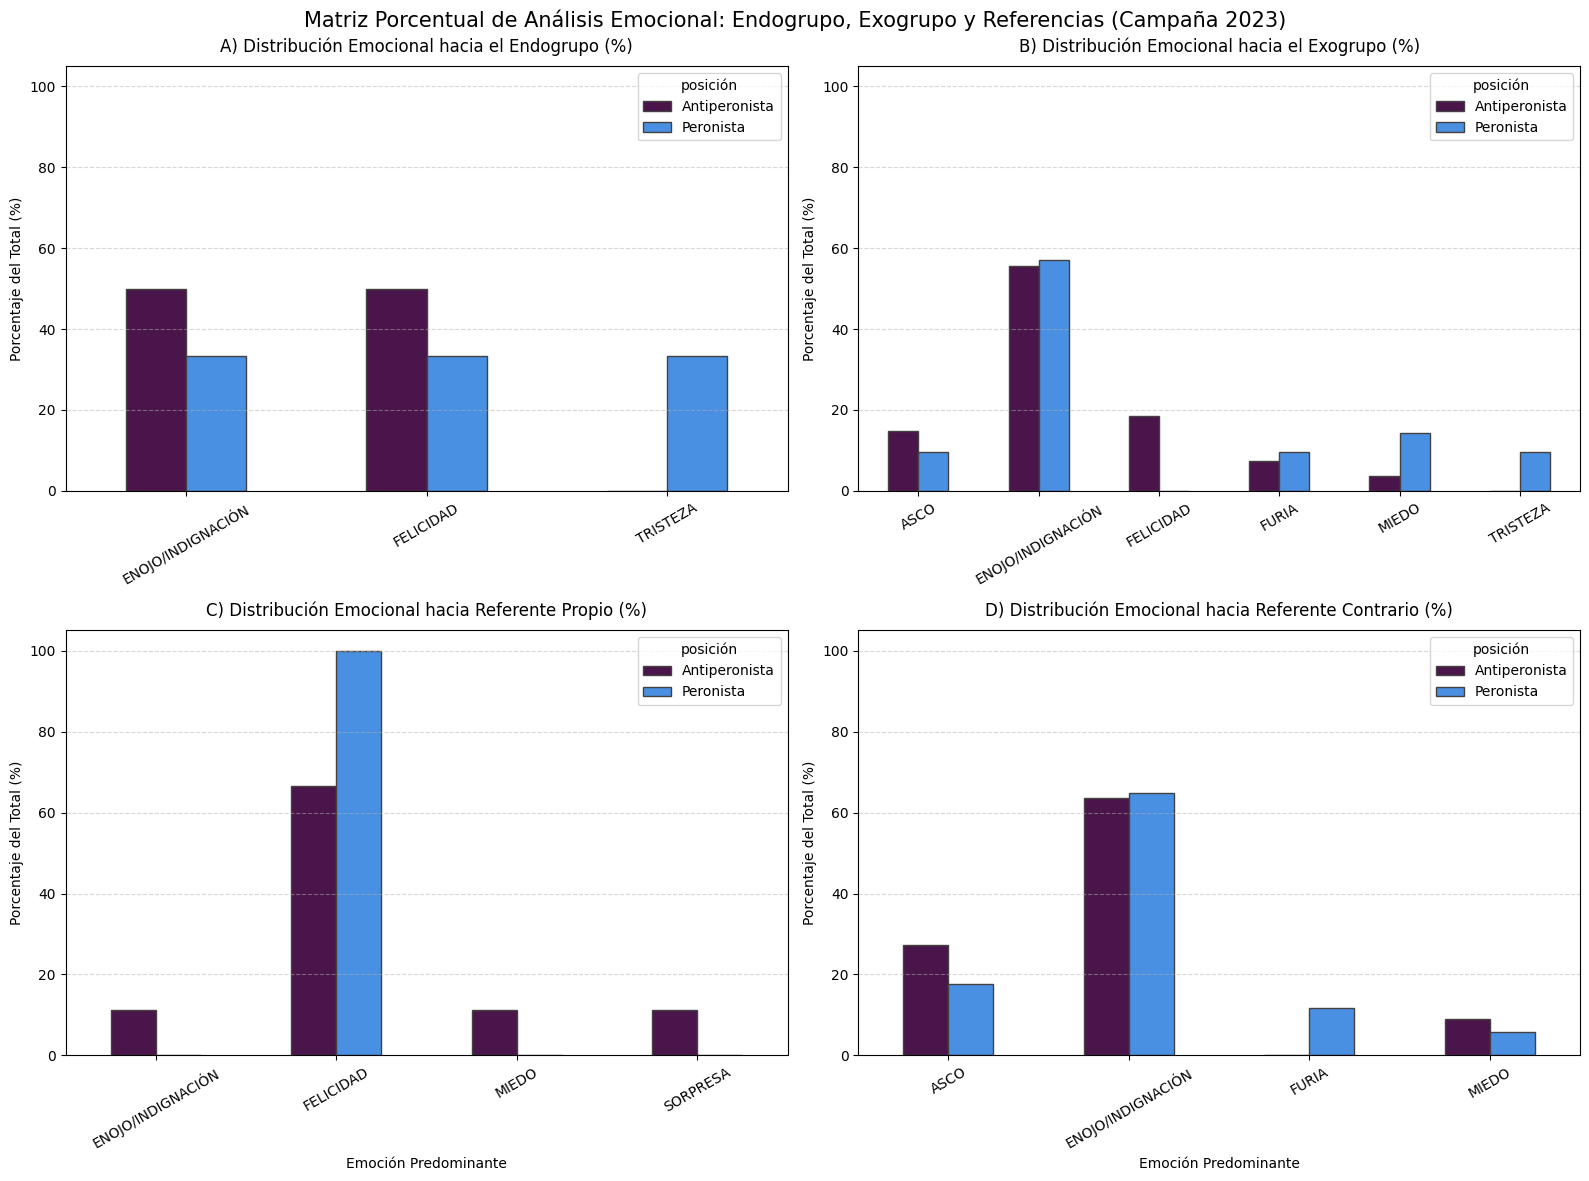

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Copia y preparación del DataFrame de Campaña 2023
df_plot = df_campana_2023.copy()

# Unificamos variantes de alegría en felicidad
df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
    'ALEGRÍA': 'FELICIDAD',
    'Alegría': 'FELICIDAD',
    'alegría': 'felicidad'
})

columna_destinatario = 'destinatario_de_la_promoción/detracción'
df_plot[columna_destinatario] = df_plot[columna_destinatario].astype(str).str.strip()

# 2. Creamos la tabla cruzada general desglosando por Emoción, Destinatario y Posición
tabla_emociones_destinatario = pd.pivot_table(
    df_plot,
    index='emoción_predominante',
    columns=[columna_destinatario, 'posición'],
    aggfunc='size',
    fill_value=0
)

# Convertimos los valores absolutos a porcentajes por cada columna (cada combinación de destinatario y posición)
tabla_porcentual = tabla_emociones_destinatario.div(tabla_emociones_destinatario.sum(axis=0), axis=1) * 100

# 3. Configuración de la figura con 4 subplots en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax_endo, ax_exo = axes[0, 0], axes[0, 1]
ax_propio, ax_contrario = axes[1, 0], axes[1, 1]

colores_barras = ['#4a154b', '#4a90e2'] # Antiperonista y Peronista

# Función auxiliar para encontrar la categoría exacta en las columnas del pivot porcentual
def obtener_sub_df_pct(keyword):
    match_col = next((col for col in tabla_porcentual.columns.levels[0] if keyword.lower() in str(col).lower()), None)
    if match_col:
        sub_df = tabla_porcentual[match_col]
        return sub_df[sub_df.sum(axis=1) > 0] # Filtramos filas vacías
    return None

# --- SUBPLOT 1: ENDOGRUPO ---
df_e = obtener_sub_df_pct('endogrupo')
if df_e is not None:
    df_e.plot(kind='bar', ax=ax_endo, color=colores_barras, edgecolor='#444140', linewidth=1, legend=True)
    ax_endo.set_title('A) Distribución Emocional hacia el Endogrupo (%)', fontsize=12, pad=10)
    ax_endo.set_xlabel('')
    ax_endo.set_ylabel('Porcentaje del Total (%)', fontsize=10)
    ax_endo.set_ylim(0, 105)
    ax_endo.tick_params(axis='x', rotation=30)
    ax_endo.grid(axis='y', linestyle='--', alpha=0.5)
else:
    ax_endo.text(0.5, 0.5, 'Sin datos de Endogrupo', ha='center', va='center')

# --- SUBPLOT 2: EXOGRUPO ---
df_ex = obtener_sub_df_pct('exogrupo')
if df_ex is not None:
    df_ex.plot(kind='bar', ax=ax_exo, color=colores_barras, edgecolor='#444140', linewidth=1, legend=True)
    ax_exo.set_title('B) Distribución Emocional hacia el Exogrupo (%)', fontsize=12, pad=10)
    ax_exo.set_xlabel('')
    ax_exo.set_ylabel('Porcentaje del Total (%)', fontsize=10)
    ax_exo.set_ylim(0, 105)
    ax_exo.tick_params(axis='x', rotation=30)
    ax_exo.grid(axis='y', linestyle='--', alpha=0.5)
else:
    ax_exo.text(0.5, 0.5, 'Sin datos de Exogrupo', ha='center', va='center')

# --- SUBPLOT 3: REFERENTE PROPIO ---
df_p = obtener_sub_df_pct('propio')
if df_p is not None:
    df_p.plot(kind='bar', ax=ax_propio, color=colores_barras, edgecolor='#444140', linewidth=1, legend=True)
    ax_propio.set_title('C) Distribución Emocional hacia Referente Propio (%)', fontsize=12, pad=10)
    ax_propio.set_xlabel('Emoción Predominante', fontsize=10)
    ax_propio.set_ylabel('Porcentaje del Total (%)', fontsize=10)
    ax_propio.set_ylim(0, 105)
    ax_propio.tick_params(axis='x', rotation=30)
    ax_propio.grid(axis='y', linestyle='--', alpha=0.5)
else:
    ax_propio.text(0.5, 0.5, 'Sin datos de Referente Propio', ha='center', va='center')

# --- SUBPLOT 4: REFERENTE CONTRARIO ---
df_c = obtener_sub_df_pct('contrario')
if df_c is not None:
    df_c.plot(kind='bar', ax=ax_contrario, color=colores_barras, edgecolor='#444140', linewidth=1, legend=True)
    ax_contrario.set_title('D) Distribución Emocional hacia Referente Contrario (%)', fontsize=12, pad=10)
    ax_contrario.set_xlabel('Emoción Predominante', fontsize=10)
    ax_contrario.set_ylabel('Porcentaje del Total (%)', fontsize=10)
    ax_contrario.set_ylim(0, 105)
    ax_contrario.tick_params(axis='x', rotation=30)
    ax_contrario.grid(axis='y', linestyle='--', alpha=0.5)
else:
    ax_contrario.text(0.5, 0.5, 'Sin datos de Referente Contrario', ha='center', va='center')

# Título general de la figura
fig.suptitle('Matriz Porcentual de Análisis Emocional: Endogrupo, Exogrupo y Referencias (Campaña 2023)', fontsize=15, y=0.98)

plt.tight_layout()
plt.show()

## Frecuencia de destinatario (2023)

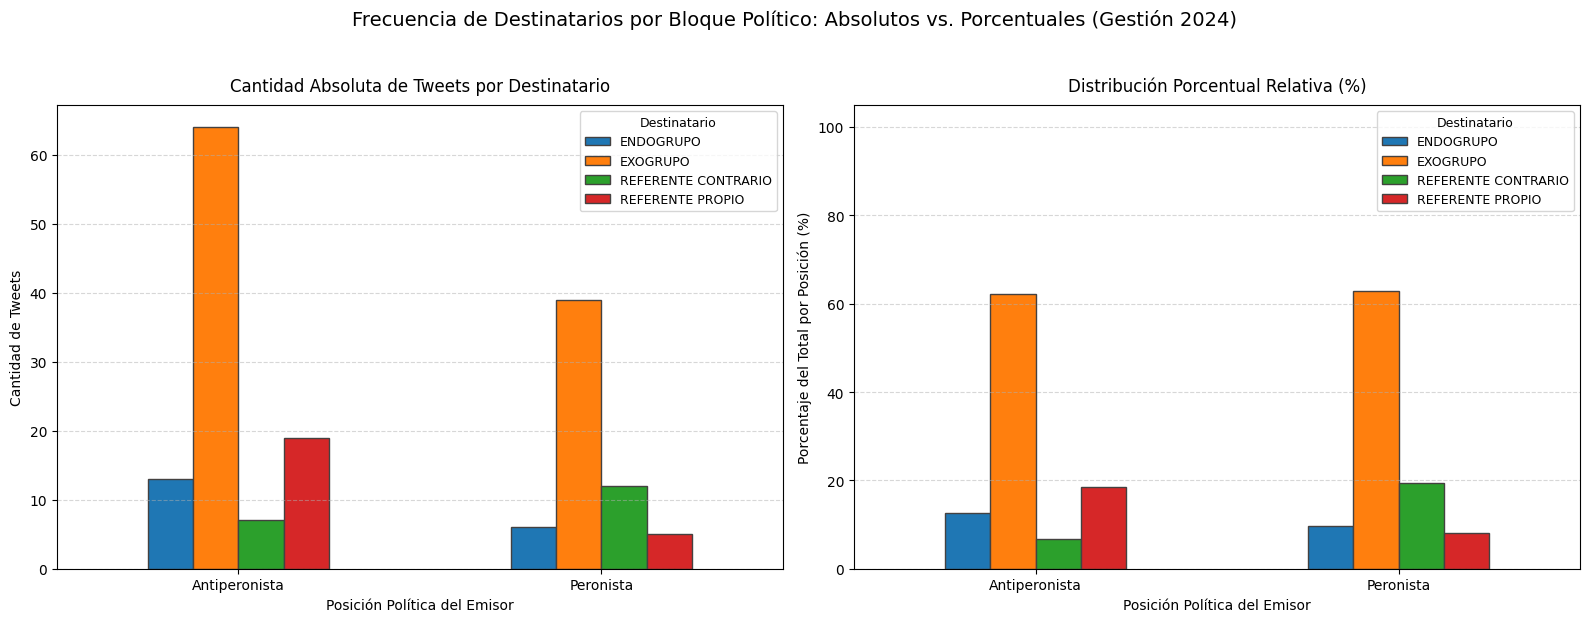

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Copia y preparación del DataFrame
df_plot = df_gestion_2024.copy()
columna_destinatario = 'destinatario_de_la_promoción/detracción'

# Limpiamos, normalizamos texto y corregimos el error tipográfico
df_plot[columna_destinatario] = (
    df_plot[columna_destinatario]
    .astype(str)
    .str.strip()
    .replace({
        'REFERENTE COTNRARIO': 'REFERENTE CONTRARIO',
        'referente cotnrario': 'referente contrario'
    })
)

# 2. Creamos la tabla cruzada general (Posición vs Destinatario)
tabla_absoluta = pd.crosstab(
    df_plot['posición'],
    df_plot[columna_destinatario]
)

# Creamos también la tabla en porcentajes por fila (para que cada posición sume 100%)
tabla_porcentual = tabla_absoluta.div(tabla_absoluta.sum(axis=1), axis=0) * 100

# 3. Configuración de la figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colores_barras = ['#4a154b', '#4a90e2'] # Ajustá según tus posiciones políticas

# --- SUBPLOT 1: CANTIDAD ABSOLUTA ---
tabla_absoluta.plot(
    kind='bar',
    ax=ax1,
    edgecolor='#444140',
    linewidth=1,
    rot=0
)
ax1.set_title('Cantidad Absoluta de Tweets por Destinatario', fontsize=12, pad=10)
ax1.set_xlabel('Posición Política del Emisor', fontsize=10)
ax1.set_ylabel('Cantidad de Tweets', fontsize=10)
ax1.legend(title='Destinatario', fontsize=9, title_fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- SUBPLOT 2: DISTRIBUCIÓN PORCENTUAL ---
tabla_porcentual.plot(
    kind='bar',
    ax=ax2,
    edgecolor='#444140',
    linewidth=1,
    rot=0
)
ax2.set_title('Distribución Porcentual Relativa (%)', fontsize=12, pad=10)
ax2.set_xlabel('Posición Política del Emisor', fontsize=10)
ax2.set_ylabel('Porcentaje del Total por Posición (%)', fontsize=10)
ax2.set_ylim(0, 105) # Margen cómodo para las etiquetas o lectura visual
ax2.legend(title='Destinatario', fontsize=9, title_fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Título general
fig.suptitle('Frecuencia de Destinatarios por Bloque Político: Absolutos vs. Porcentuales (Gestión 2024)', fontsize=14, y=1.03)

plt.tight_layout()
plt.show()

# **Primer año de gestión presidencial (2024)**

## Emociones durante la gestión 2024

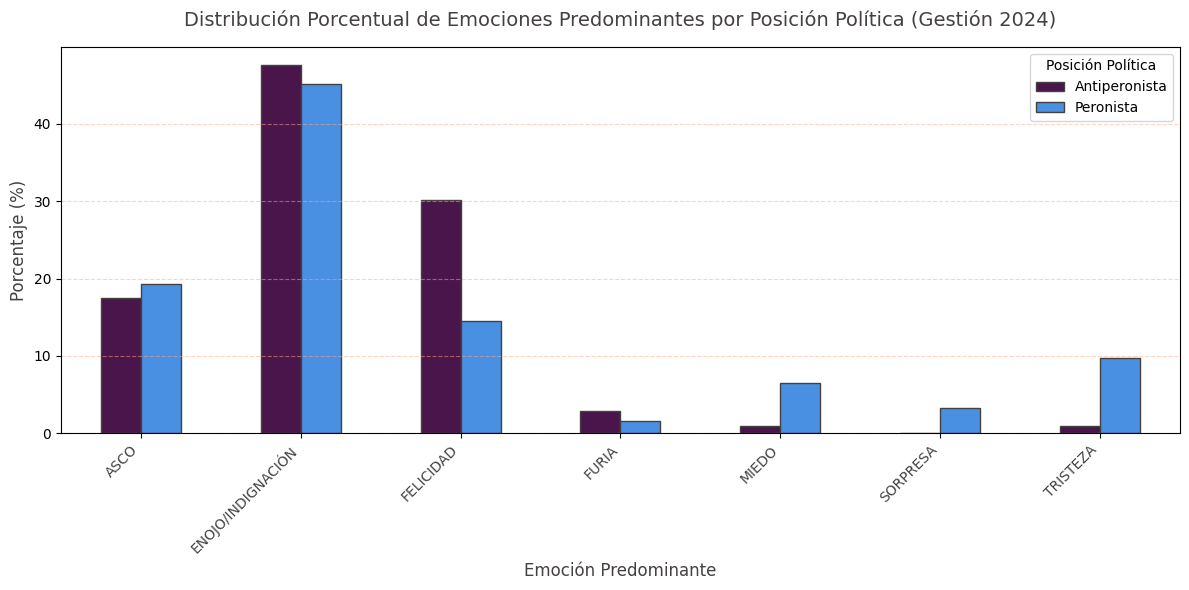

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Copia y unificación de Alegría en Felicidad usando df_gestion_2024
df_plot = df_gestion_2024.copy()
if 'emoción_predominante' in df_plot.columns:
    df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
        'ALEGRÍA': 'FELICIDAD',
        'Alegría': 'FELICIDAD',
        'alegría': 'felicidad'
    })

# Tabla cruzada normalizada en porcentaje por posición política
tabla_emociones = pd.crosstab(
    df_plot['emoción_predominante'],
    df_plot['posición'],
    normalize='columns'
) * 100

# Definimos la lista de colores para las barras en el mismo orden de las columnas de la tabla
colores_barras = ['#4a154b', '#4a90e2'] # Ajusta el orden según corresponda a antiperonista/peronista

ax = tabla_emociones.plot(
    kind='bar',
    figsize=(12, 6),
    color=colores_barras,
    edgecolor='#444140',
    linewidth=1,
    grid=False
)

plt.title('Distribución Porcentual de Emociones Predominantes por Posición Política (Gestión 2024)', fontsize=14, color='#444140', pad=15)
plt.xlabel('Emoción Predominante', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.xticks(rotation=45, ha='right', color='#444140')
plt.legend(title='Posición Política')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

## Promoción y detracción durante el año 2024

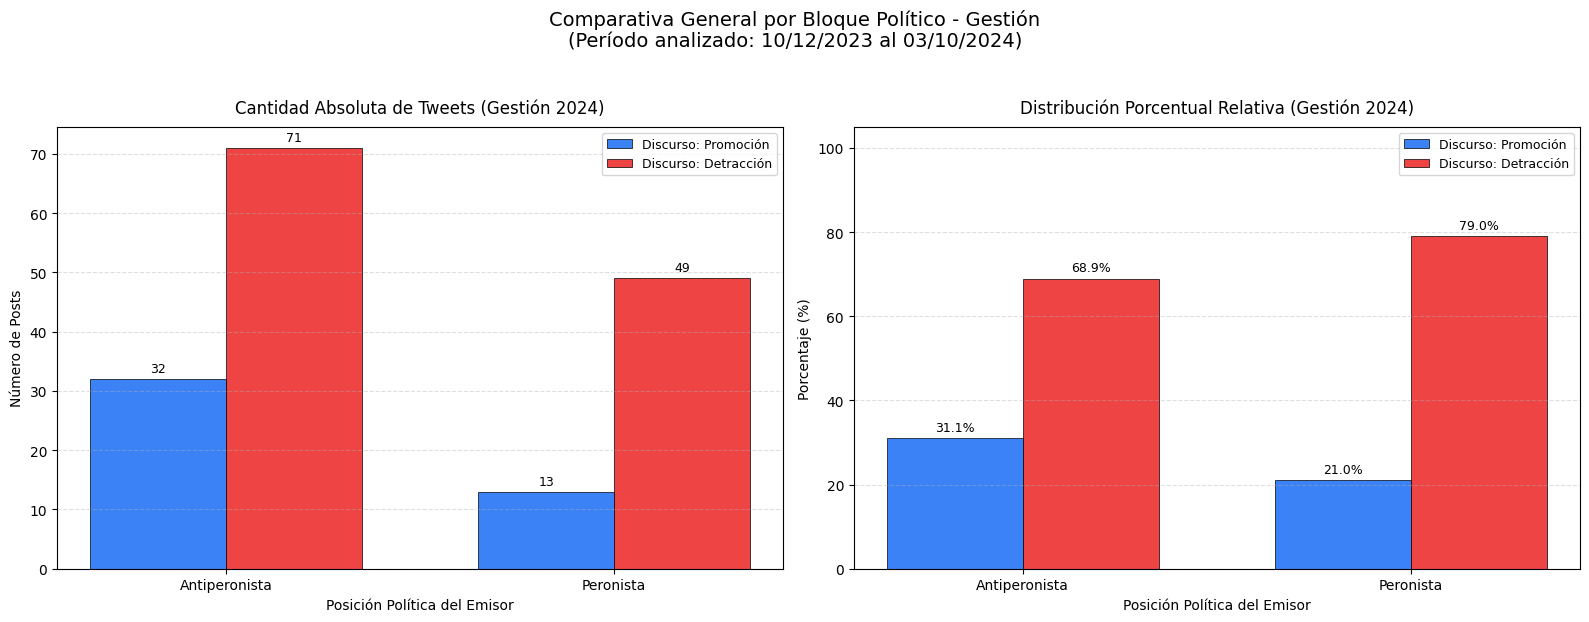

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Copia y preparación del DataFrame limpio usando df_gestion_2024
df_plot = df_gestion_2024.reset_index().copy()

# Normalizamos la columna objetivo
columna_objetivo = 'promoción/apoyo_o_detracción/ataque'
df_plot[columna_objetivo] = (
    df_plot[columna_objetivo]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'promocion': 'promoción',
        'detraccion': 'detracción'
    })
)

# Convertimos fechas para hallar el rango real
df_plot['fecha_dt'] = pd.to_datetime(df_plot['fecha'], errors='coerce')
fecha_min = df_plot['fecha_dt'].min().strftime('%d/%m/%Y')
fecha_max = df_plot['fecha_dt'].max().strftime('%d/%m/%Y')

# 2. Creamos la tabla cruzada general por posición y tipo de discurso
tabla_general = pd.crosstab(
    df_plot['posición'],
    df_plot[columna_objetivo]
)

# Aseguramos que existan ambas columnas (promoción y detracción)
categorias_fijas = ['promoción', 'detracción']
for cat in categorias_fijas:
    if cat not in tabla_general.columns:
        tabla_general[cat] = 0
tabla_general = tabla_general[categorias_fijas]

# Creamos también una tabla en porcentajes por fila para el segundo subplot
tabla_porcentual = tabla_general.div(tabla_general.sum(axis=1), axis=0) * 100

# 3. Configuración de la figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

posiciones = tabla_general.index
x = np.arange(len(posiciones))
ancho_barra = 0.35

colores_discurso = {
    'promoción': '#3b82f6',   # Azul
    'detracción': '#ef4444'   # Rojo
}

# --- PRIMER SUPLOT: Cantidad Absoluta de Posts ---
for i, tipo in enumerate(categorias_fijas):
    valores = tabla_general[tipo].values
    offset = (i - 0.5) * ancho_barra

    barras1 = ax1.bar(
        x + offset, valores, width=ancho_barra,
        label=f'Discurso: {tipo.capitalize()}',
        color=colores_discurso[tipo], edgecolor='black', linewidth=0.5
    )
    ax1.bar_label(barras1, padding=3, fontsize=9)

ax1.set_title('Cantidad Absoluta de Tweets (Gestión 2024)', fontsize=12, pad=10)
ax1.set_xlabel('Posición Política del Emisor', fontsize=10)
ax1.set_ylabel('Número de Posts', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(posiciones, rotation=0, fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4, axis='y')

# --- SEGUNDO SUPLOT: Distribución Porcentual (%) ---
for i, tipo in enumerate(categorias_fijas):
    valores = tabla_porcentual[tipo].values
    offset = (i - 0.5) * ancho_barra

    barras2 = ax2.bar(
        x + offset, valores, width=ancho_barra,
        label=f'Discurso: {tipo.capitalize()}',
        color=colores_discurso[tipo], edgecolor='black', linewidth=0.5
    )
    # Agregamos el "%" a las etiquetas
    ax2.bar_label(barras2, labels=[f'{v:.1f}%' for v in valores], padding=3, fontsize=9)

ax2.set_title('Distribución Porcentual Relativa (Gestión 2024)', fontsize=12, pad=10)
ax2.set_xlabel('Posición Política del Emisor', fontsize=10)
ax2.set_ylabel('Porcentaje (%)', fontsize=10)
ax2.set_ylim(0, 105) # Margen para que las etiquetas entren cómodas
ax2.set_xticks(x)
ax2.set_xticklabels(posiciones, rotation=0, fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4, axis='y')

# Título general para toda la figura indicando el período
fig.suptitle(f'Comparativa General por Bloque Político - Gestión\n(Período analizado: {fecha_min} al {fecha_max})', fontsize=14, y=1.03)

plt.tight_layout()
plt.show()

## Emociones por endogrupo, referente propio, referente contrario y exogrupo (2024)

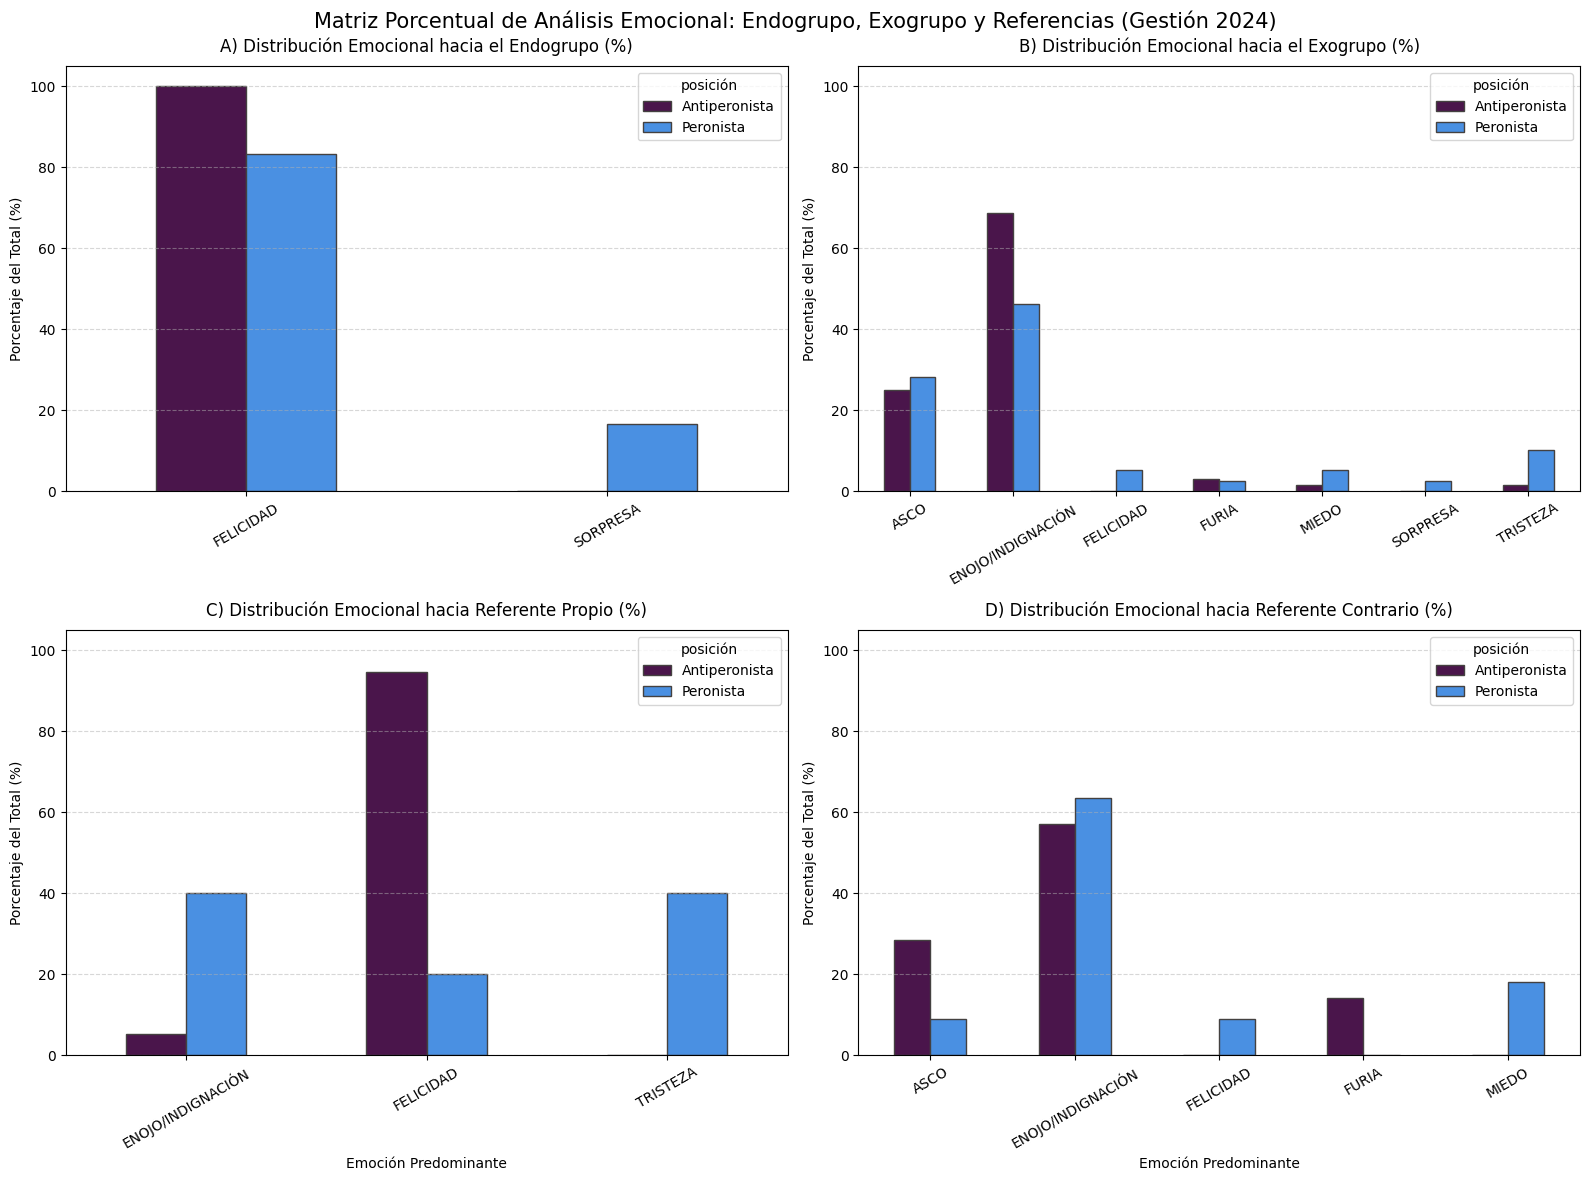

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Copia y preparación del DataFrame
df_plot = df_gestion_2024.copy()

# Unificamos variantes de alegría en felicidad
df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
    'ALEGRÍA': 'FELICIDAD',
    'Alegría': 'FELICIDAD',
    'alegría': 'felicidad'
})

columna_destinatario = 'destinatario_de_la_promoción/detracción'
df_plot[columna_destinatario] = df_plot[columna_destinatario].astype(str).str.strip()

# 2. Creamos la tabla cruzada general desglosando por Emoción, Destinatario y Posición
tabla_emociones_destinatario = pd.pivot_table(
    df_plot,
    index='emoción_predominante',
    columns=[columna_destinatario, 'posición'],
    aggfunc='size',
    fill_value=0
)

# Convertimos los valores absolutos a porcentajes por cada columna (cada combinación de destinatario y posición)
# Esto asegura que para cada barra/grupo de posición se distribuya el 100% de sus emociones en esa categoría
tabla_porcentual = tabla_emociones_destinatario.div(tabla_emociones_destinatario.sum(axis=0), axis=1) * 100

# 3. Configuración de la figura con 4 subplots en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax_endo, ax_exo = axes[0, 0], axes[0, 1]
ax_propio, ax_contrario = axes[1, 0], axes[1, 1]

colores_barras = ['#4a154b', '#4a90e2'] # Antiperonista y Peronista

# Función auxiliar para encontrar la categoría exacta en las columnas del pivot porcentual
def obtener_sub_df_pct(keyword):
    match_col = next((col for col in tabla_porcentual.columns.levels[0] if keyword.lower() in str(col).lower()), None)
    if match_col:
        sub_df = tabla_porcentual[match_col]
        return sub_df[sub_df.sum(axis=1) > 0] # Filtramos filas vacías
    return None

# --- SUBPLOT 1: ENDOGRUPO ---
df_e = obtener_sub_df_pct('endogrupo')
if df_e is not None:
    df_e.plot(kind='bar', ax=ax_endo, color=colores_barras, edgecolor='#444140', linewidth=1, legend=True)
    ax_endo.set_title('A) Distribución Emocional hacia el Endogrupo (%)', fontsize=12, pad=10)
    ax_endo.set_xlabel('')
    ax_endo.set_ylabel('Porcentaje del Total (%)', fontsize=10)
    ax_endo.set_ylim(0, 105)
    ax_endo.tick_params(axis='x', rotation=30)
    ax_endo.grid(axis='y', linestyle='--', alpha=0.5)
else:
    ax_endo.text(0.5, 0.5, 'Sin datos de Endogrupo', ha='center', va='center')

# --- SUBPLOT 2: EXOGRUPO ---
df_ex = obtener_sub_df_pct('exogrupo')
if df_ex is not None:
    df_ex.plot(kind='bar', ax=ax_exo, color=colores_barras, edgecolor='#444140', linewidth=1, legend=True)
    ax_exo.set_title('B) Distribución Emocional hacia el Exogrupo (%)', fontsize=12, pad=10)
    ax_exo.set_xlabel('')
    ax_exo.set_ylabel('Porcentaje del Total (%)', fontsize=10)
    ax_exo.set_ylim(0, 105)
    ax_exo.tick_params(axis='x', rotation=30)
    ax_exo.grid(axis='y', linestyle='--', alpha=0.5)
else:
    ax_exo.text(0.5, 0.5, 'Sin datos de Exogrupo', ha='center', va='center')

# --- SUBPLOT 3: REFERENTE PROPIO ---
df_p = obtener_sub_df_pct('propio')
if df_p is not None:
    df_p.plot(kind='bar', ax=ax_propio, color=colores_barras, edgecolor='#444140', linewidth=1, legend=True)
    ax_propio.set_title('C) Distribución Emocional hacia Referente Propio (%)', fontsize=12, pad=10)
    ax_propio.set_xlabel('Emoción Predominante', fontsize=10)
    ax_propio.set_ylabel('Porcentaje del Total (%)', fontsize=10)
    ax_propio.set_ylim(0, 105)
    ax_propio.tick_params(axis='x', rotation=30)
    ax_propio.grid(axis='y', linestyle='--', alpha=0.5)
else:
    ax_propio.text(0.5, 0.5, 'Sin datos de Referente Propio', ha='center', va='center')

# --- SUBPLOT 4: REFERENTE CONTRARIO ---
df_c = obtener_sub_df_pct('contrario')
if df_c is not None:
    df_c.plot(kind='bar', ax=ax_contrario, color=colores_barras, edgecolor='#444140', linewidth=1, legend=True)
    ax_contrario.set_title('D) Distribución Emocional hacia Referente Contrario (%)', fontsize=12, pad=10)
    ax_contrario.set_xlabel('Emoción Predominante', fontsize=10)
    ax_contrario.set_ylabel('Porcentaje del Total (%)', fontsize=10)
    ax_contrario.set_ylim(0, 105)
    ax_contrario.tick_params(axis='x', rotation=30)
    ax_contrario.grid(axis='y', linestyle='--', alpha=0.5)
else:
    ax_contrario.text(0.5, 0.5, 'Sin datos de Referente Contrario', ha='center', va='center')

# Título general de la figura
fig.suptitle('Matriz Porcentual de Análisis Emocional: Endogrupo, Exogrupo y Referencias (Gestión 2024)', fontsize=15, y=0.98)

plt.tight_layout()
plt.show()

## Frecuencia de destinatario (2024)

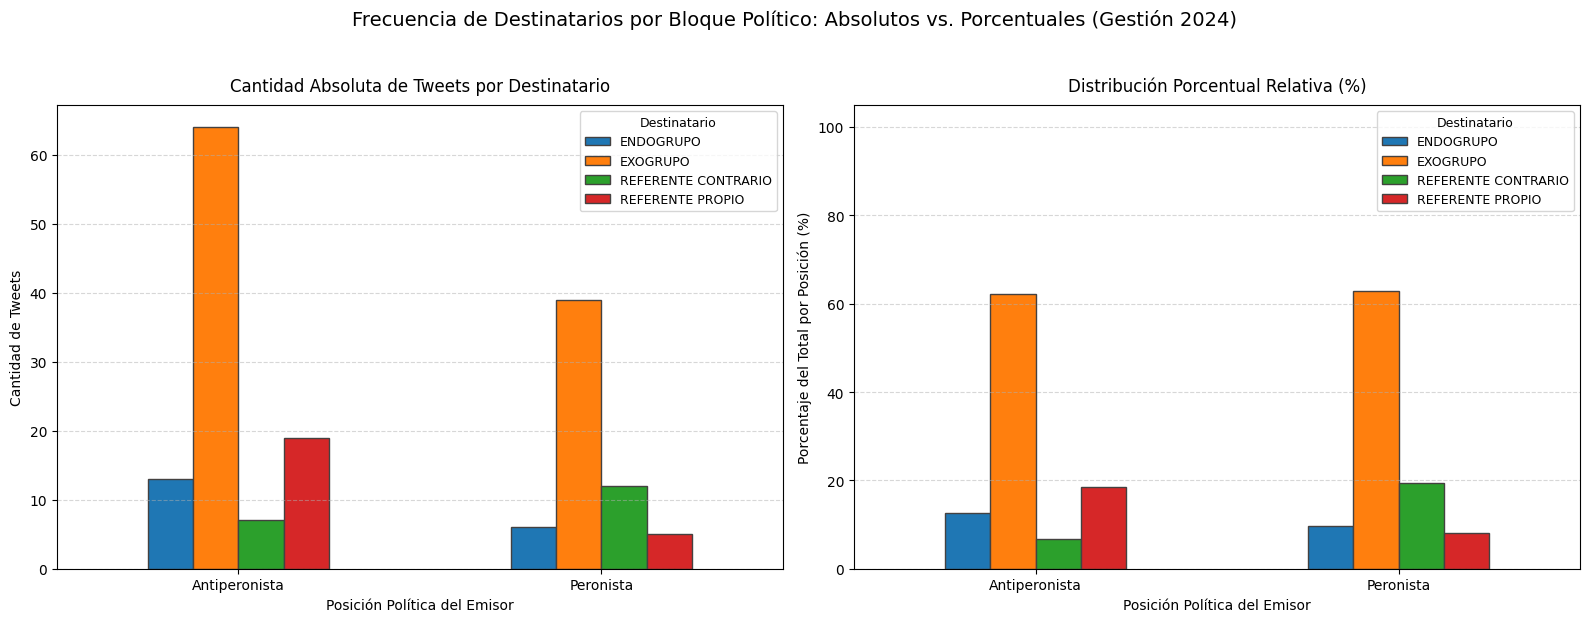

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Copia y preparación del DataFrame
df_plot = df_gestion_2024.copy()
columna_destinatario = 'destinatario_de_la_promoción/detracción'

# Limpiamos y unificamos el error tipográfico de "cotnrario" a "contrario"
df_plot[columna_destinatario] = (
    df_plot[columna_destinatario]
    .astype(str)
    .str.strip()
    .replace({
        'REFERENTE COTNRARIO': 'REFERENTE CONTRARIO',
        'referente cotnrario': 'referente contrario',
        'Referente cotnrario': 'Referente contrario'
    })
)

# 2. Creamos la tabla cruzada general (Posición vs Destinatario)
tabla_absoluta = pd.crosstab(
    df_plot['posición'],
    df_plot[columna_destinatario]
)

# Creamos también la tabla en porcentajes por fila (para que cada posición sume 100%)
tabla_porcentual = tabla_absoluta.div(tabla_absoluta.sum(axis=1), axis=0) * 100

# 3. Configuración de la figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colores_barras = ['#4a154b', '#4a90e2'] # Ajustá según tus posiciones políticas

# --- SUBPLOT 1: CANTIDAD ABSOLUTA ---
tabla_absoluta.plot(
    kind='bar',
    ax=ax1,
    edgecolor='#444140',
    linewidth=1,
    rot=0
)
ax1.set_title('Cantidad Absoluta de Tweets por Destinatario', fontsize=12, pad=10)
ax1.set_xlabel('Posición Política del Emisor', fontsize=10)
ax1.set_ylabel('Cantidad de Tweets', fontsize=10)
ax1.legend(title='Destinatario', fontsize=9, title_fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- SUBPLOT 2: DISTRIBUCIÓN PORCENTUAL ---
tabla_porcentual.plot(
    kind='bar',
    ax=ax2,
    edgecolor='#444140',
    linewidth=1,
    rot=0
)
ax2.set_title('Distribución Porcentual Relativa (%)', fontsize=12, pad=10)
ax2.set_xlabel('Posición Política del Emisor', fontsize=10)
ax2.set_ylabel('Porcentaje del Total por Posición (%)', fontsize=10)
ax2.set_ylim(0, 105) # Margen cómodo para las etiquetas o lectura visual
ax2.legend(title='Destinatario', fontsize=9, title_fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Título general
fig.suptitle('Frecuencia de Destinatarios por Bloque Político: Absolutos vs. Porcentuales (Gestión 2024)', fontsize=14, y=1.03)

plt.tight_layout()
plt.show()

# **Gestion 2025**

## Emociones durante la gestión 2025

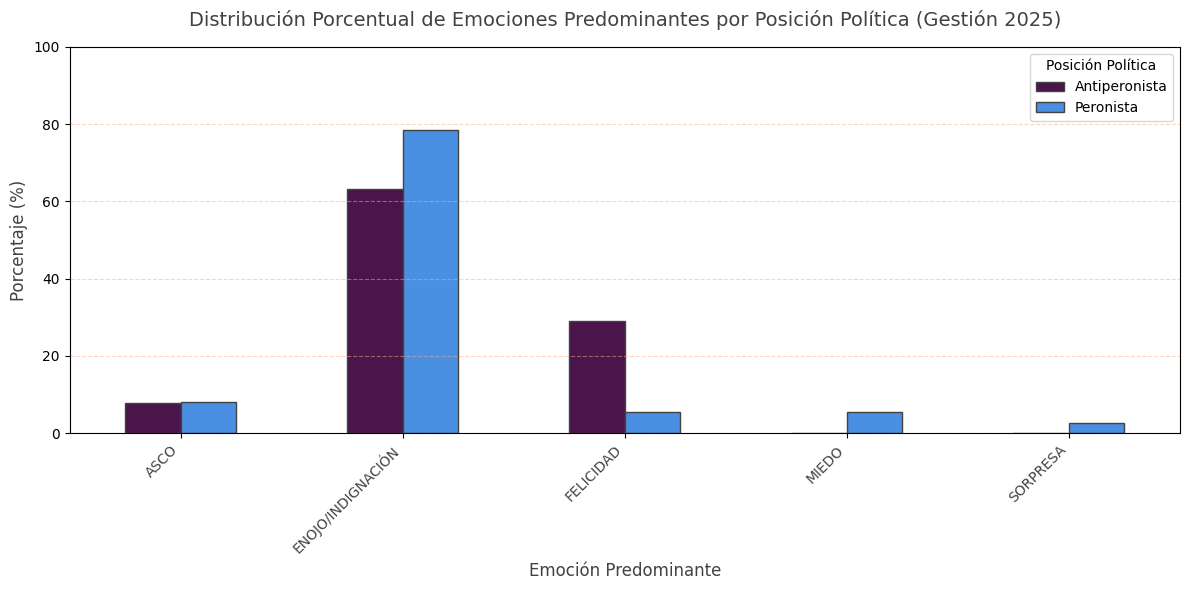

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# Copia y unificación de Alegría en Felicidad para la gestión 2025
df_plot = df_gestion_2025.copy()
df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
    'ALEGRÍA': 'FELICIDAD',
    'Alegría': 'FELICIDAD',
    'alegría': 'felicidad'
})

# Tabla cruzada para calcular porcentajes (normalizada por columnas) y multiplicada por 100
tabla_emociones = pd.crosstab(df_plot['emoción_predominante'], df_plot['posición'], normalize='columns') * 100

# Definimos la lista de colores para las barras en el mismo orden de las columnas de la tabla
colores_barras = ['#4a154b', '#4a90e2'] # Ajusta el orden según corresponda a antiperonista/peronista

ax = tabla_emociones.plot(
    kind='bar',
    figsize=(12, 6),
    color=colores_barras,
    edgecolor='#444140',
    linewidth=1
)

plt.title('Distribución Porcentual de Emociones Predominantes por Posición Política (Gestión 2025)', fontsize=14, color='#444140', pad=15)
plt.xlabel('Emoción Predominante', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right', color='#444140')
plt.legend(title='Posición Política')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

## Promoción y detracción durante la gestión 2025

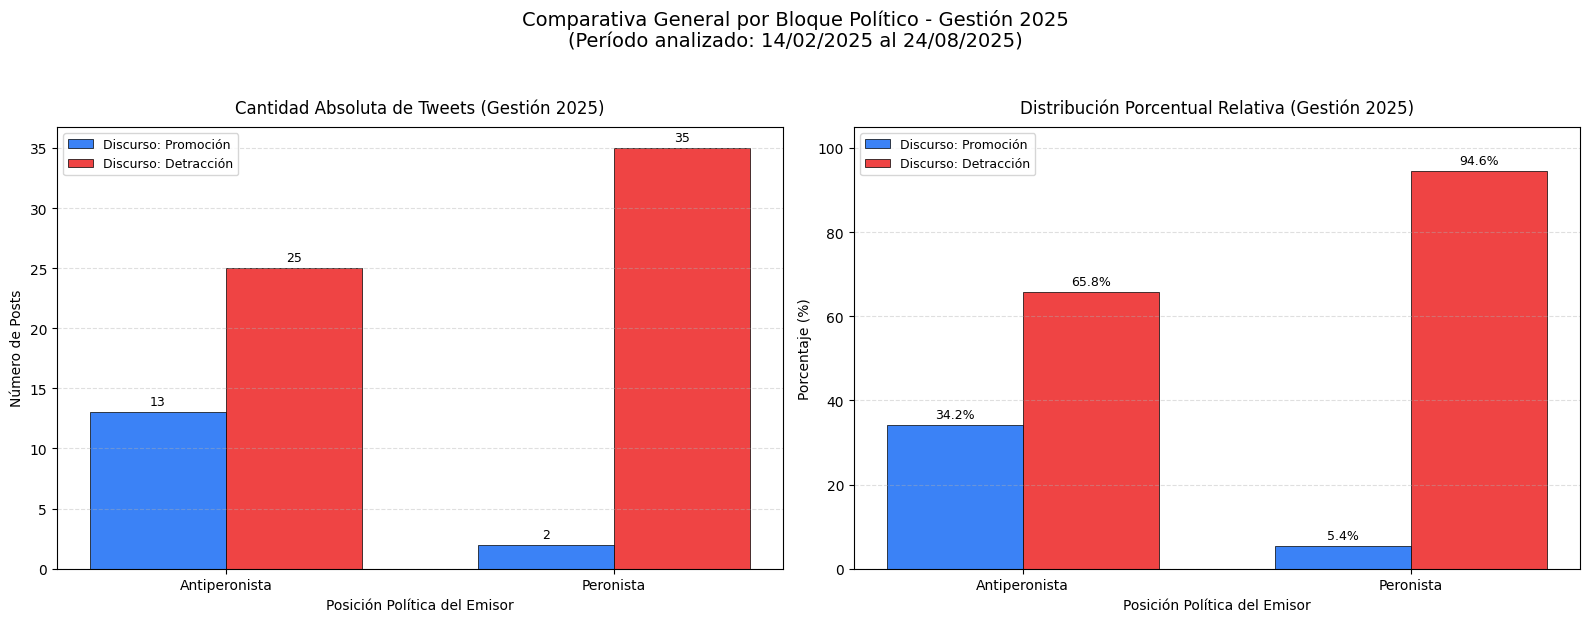

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Copia y preparación del DataFrame limpio usando df_gestion_2025
df_plot = df_gestion_2025.reset_index().copy()

# Normalizamos la columna objetivo
columna_objetivo = 'promoción/apoyo_o_detracción/ataque'
df_plot[columna_objetivo] = (
    df_plot[columna_objetivo]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'promocion': 'promoción',
        'detraccion': 'detracción'
    })
)

# Convertimos fechas para hallar el rango real
df_plot['fecha_dt'] = pd.to_datetime(df_plot['fecha'], errors='coerce')
fecha_min = df_plot['fecha_dt'].min().strftime('%d/%m/%Y')
fecha_max = df_plot['fecha_dt'].max().strftime('%d/%m/%Y')

# 2. Creamos la tabla cruzada general por posición y tipo de discurso
tabla_general = pd.crosstab(
    df_plot['posición'],
    df_plot[columna_objetivo]
)

# Aseguramos que existan ambas columnas (promoción y detracción)
categorias_fijas = ['promoción', 'detracción']
for cat in categorias_fijas:
    if cat not in tabla_general.columns:
        tabla_general[cat] = 0
tabla_general = tabla_general[categorias_fijas]

# Creamos también una tabla en porcentajes por fila para el segundo subplot
tabla_porcentual = tabla_general.div(tabla_general.sum(axis=1), axis=0) * 100

# 3. Configuración de la figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

posiciones = tabla_general.index
x = np.arange(len(posiciones))
ancho_barra = 0.35

colores_discurso = {
    'promoción': '#3b82f6',   # Azul
    'detracción': '#ef4444'   # Rojo
}

# --- PRIMER SUPLOT: Cantidad Absoluta de Posts ---
for i, tipo in enumerate(categorias_fijas):
    valores = tabla_general[tipo].values
    offset = (i - 0.5) * ancho_barra

    barras1 = ax1.bar(
        x + offset, valores, width=ancho_barra,
        label=f'Discurso: {tipo.capitalize()}',
        color=colores_discurso[tipo], edgecolor='black', linewidth=0.5
    )
    ax1.bar_label(barras1, padding=3, fontsize=9)

ax1.set_title('Cantidad Absoluta de Tweets (Gestión 2025)', fontsize=12, pad=10)
ax1.set_xlabel('Posición Política del Emisor', fontsize=10)
ax1.set_ylabel('Número de Posts', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(posiciones, rotation=0, fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4, axis='y')

# --- SEGUNDO SUPLOT: Distribución Porcentual (%) ---
for i, tipo in enumerate(categorias_fijas):
    valores = tabla_porcentual[tipo].values
    offset = (i - 0.5) * ancho_barra

    barras2 = ax2.bar(
        x + offset, valores, width=ancho_barra,
        label=f'Discurso: {tipo.capitalize()}',
        color=colores_discurso[tipo], edgecolor='black', linewidth=0.5
    )
    # Agregamos el "%" a las etiquetas
    ax2.bar_label(barras2, labels=[f'{v:.1f}%' for v in valores], padding=3, fontsize=9)

ax2.set_title('Distribución Porcentual Relativa (Gestión 2025)', fontsize=12, pad=10)
ax2.set_xlabel('Posición Política del Emisor', fontsize=10)
ax2.set_ylabel('Porcentaje (%)', fontsize=10)
ax2.set_ylim(0, 105) # Margen para que las etiquetas entren cómodas
ax2.set_xticks(x)
ax2.set_xticklabels(posiciones, rotation=0, fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4, axis='y')

# Título general para toda la figura indicando el período
fig.suptitle(f'Comparativa General por Bloque Político - Gestión 2025\n(Período analizado: {fecha_min} al {fecha_max})', fontsize=14, y=1.03)

plt.tight_layout()
plt.show()

## Emociones por endogrupo, referente propio, referente contrario y exogrupo durante la gestión 2025

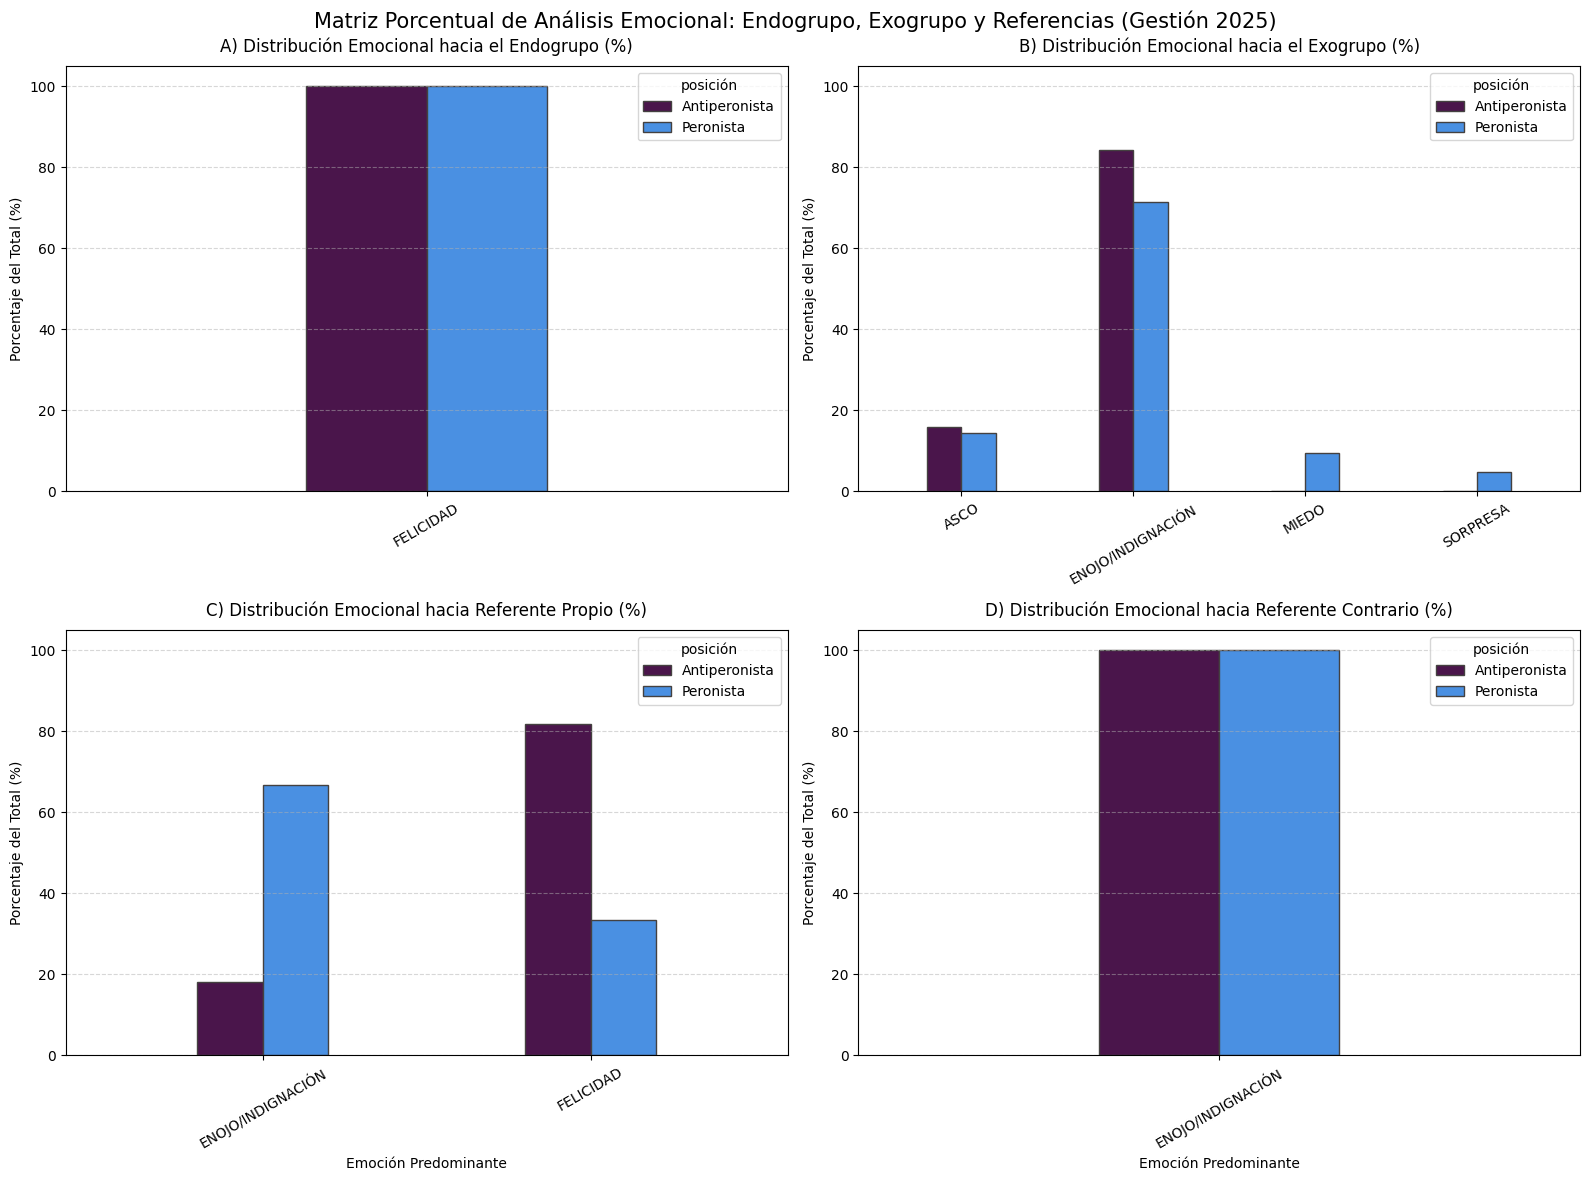

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Copia y preparación del DataFrame
df_plot = df_gestion_2025.copy()

# Unificamos variantes de alegría en felicidad
df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
    'ALEGRÍA': 'FELICIDAD',
    'Alegría': 'FELICIDAD',
    'alegría': 'felicidad'
})

columna_destinatario = 'destinatario_de_la_promoción/detracción'
df_plot[columna_destinatario] = df_plot[columna_destinatario].astype(str).str.strip()

# 2. Creamos la tabla cruzada general desglosando por Emoción, Destinatario y Posición
tabla_emociones_destinatario = pd.pivot_table(
    df_plot,
    index='emoción_predominante',
    columns=[columna_destinatario, 'posición'],
    aggfunc='size',
    fill_value=0
)

# Convertimos los valores absolutos a porcentajes por cada columna
tabla_porcentual = tabla_emociones_destinatario.div(tabla_emociones_destinatario.sum(axis=0), axis=1) * 100

# 3. Configuración de la figura con 4 subplots en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax_endo, ax_exo = axes[0, 0], axes[0, 1]
ax_propio, ax_contrario = axes[1, 0], axes[1, 1]

colores_barras = ['#4a154b', '#4a90e2'] # Antiperonista y Peronista

# Función auxiliar para obtener y formatear estéticamente cada subplot
def graficar_subplot(ax, keyword, titulo, mostrar_xlabel=False):
    match_col = next((col for col in tabla_porcentual.columns.levels[0] if keyword.lower() in str(col).lower()), None)
    if match_col is not None:
        sub_df = tabla_porcentual[match_col]
        sub_df = sub_df[sub_df.sum(axis=1) > 0] # Filtramos filas vacías

        if not sub_df.empty:
            # Usamos width y position explícitos para controlar el ancho de las barras y evitar que se expandan
            sub_df.plot(
                kind='bar',
                ax=ax,
                color=colores_barras,
                edgecolor='#444140',
                linewidth=1,
                legend=True,
                width=0.4 # Controla la delgadez de las barras (más chico = más angostas)
            )
            ax.set_title(titulo, fontsize=12, pad=10)
            ax.set_xlabel('Emoción Predominante' if mostrar_xlabel else '', fontsize=10)
            ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)
            ax.set_ylim(0, 105)

            # Control de márgenes laterales en el eje X para que las barras no toquen los bordes
            ax.set_xlim(-0.6, len(sub_df) - 0.4)

            ax.tick_params(axis='x', rotation=30)
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            return

    ax.text(0.5, 0.5, f'Sin datos de {keyword.capitalize()}', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo, fontsize=12, pad=10)

# Aplicamos la función a cada cuadrante con su respectivo título actualizado a 2025
graficar_subplot(ax_endo, 'endogrupo', 'A) Distribución Emocional hacia el Endogrupo (%)', mostrar_xlabel=False)
graficar_subplot(ax_exo, 'exogrupo', 'B) Distribución Emocional hacia el Exogrupo (%)', mostrar_xlabel=False)
graficar_subplot(ax_propio, 'propio', 'C) Distribución Emocional hacia Referente Propio (%)', mostrar_xlabel=True)
graficar_subplot(ax_contrario, 'contrario', 'D) Distribución Emocional hacia Referente Contrario (%)', mostrar_xlabel=True)

# Título general de la figura
fig.suptitle('Matriz Porcentual de Análisis Emocional: Endogrupo, Exogrupo y Referencias (Gestión 2025)', fontsize=15, y=0.98)

plt.tight_layout()
plt.show()

## Frecuencia de destinatarios (2025)

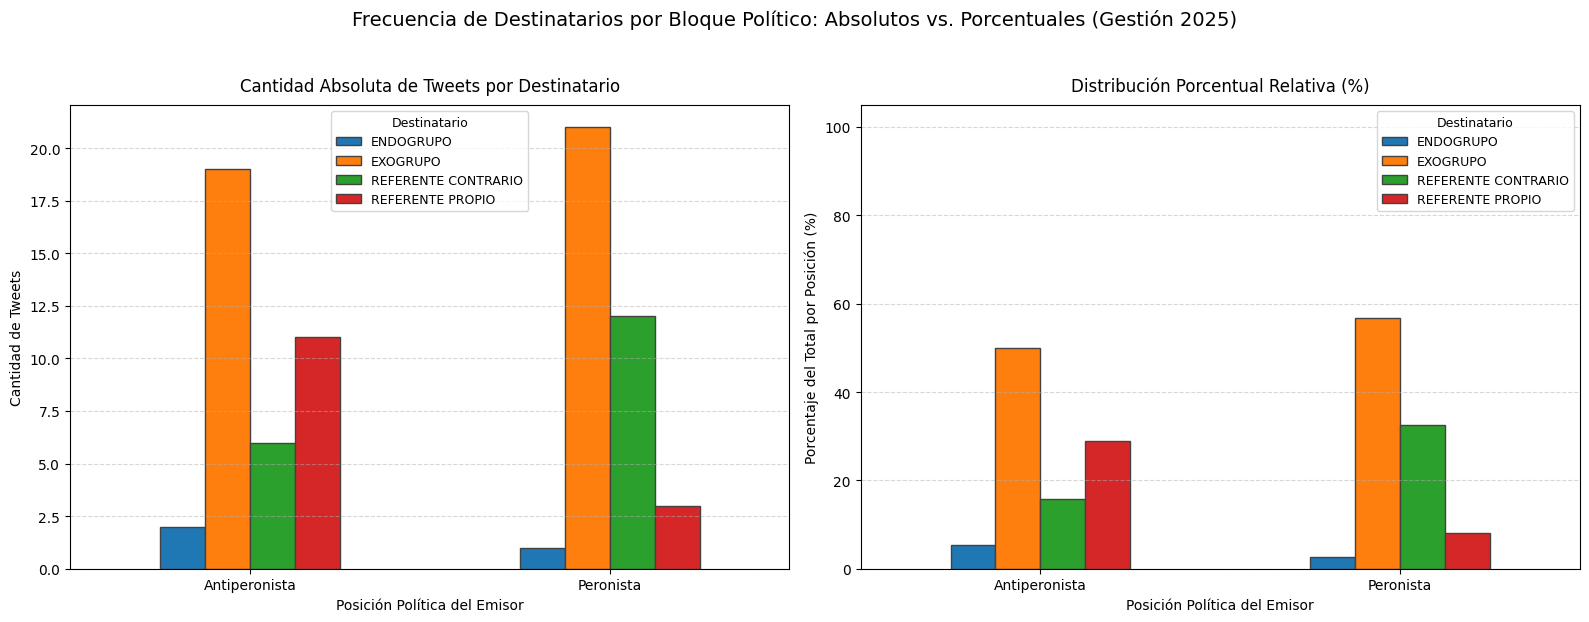

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Copia y preparación del DataFrame usando df_gestion_2025
df_plot = df_gestion_2025.copy()
columna_destinatario = 'destinatario_de_la_promoción/detracción'
df_plot[columna_destinatario] = df_plot[columna_destinatario].astype(str).str.strip()

# 2. Creamos la tabla cruzada general (Posición vs Destinatario)
tabla_absoluta = pd.crosstab(
    df_plot['posición'],
    df_plot[columna_destinatario]
)

# Creamos también la tabla en porcentajes por fila (para que cada posición sume 100%)
tabla_porcentual = tabla_absoluta.div(tabla_absoluta.sum(axis=1), axis=0) * 100

# 3. Configuración de la figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colores_barras = ['#4a154b', '#4a90e2'] # Ajustá según tus posiciones políticas

# --- SUBPLOT 1: CANTIDAD ABSOLUTA ---
tabla_absoluta.plot(
    kind='bar',
    ax=ax1,
    edgecolor='#444140',
    linewidth=1,
    rot=0
)
ax1.set_title('Cantidad Absoluta de Tweets por Destinatario', fontsize=12, pad=10)
ax1.set_xlabel('Posición Política del Emisor', fontsize=10)
ax1.set_ylabel('Cantidad de Tweets', fontsize=10)
ax1.legend(title='Destinatario', fontsize=9, title_fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- SUBPLOT 2: DISTRIBUCIÓN PORCENTUAL ---
tabla_porcentual.plot(
    kind='bar',
    ax=ax2,
    edgecolor='#444140',
    linewidth=1,
    rot=0
)
ax2.set_title('Distribución Porcentual Relativa (%)', fontsize=12, pad=10)
ax2.set_xlabel('Posición Política del Emisor', fontsize=10)
ax2.set_ylabel('Porcentaje del Total por Posición (%)', fontsize=10)
ax2.set_ylim(0, 105) # Margen cómodo para las etiquetas o lectura visual
ax2.legend(title='Destinatario', fontsize=9, title_fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Título general actualizado para 2025
fig.suptitle('Frecuencia de Destinatarios por Bloque Político: Absolutos vs. Porcentuales (Gestión 2025)', fontsize=14, y=1.03)

plt.tight_layout()
plt.show()

# **Campaña legsilativa 2025**

## Emociones durante la campaña 2025

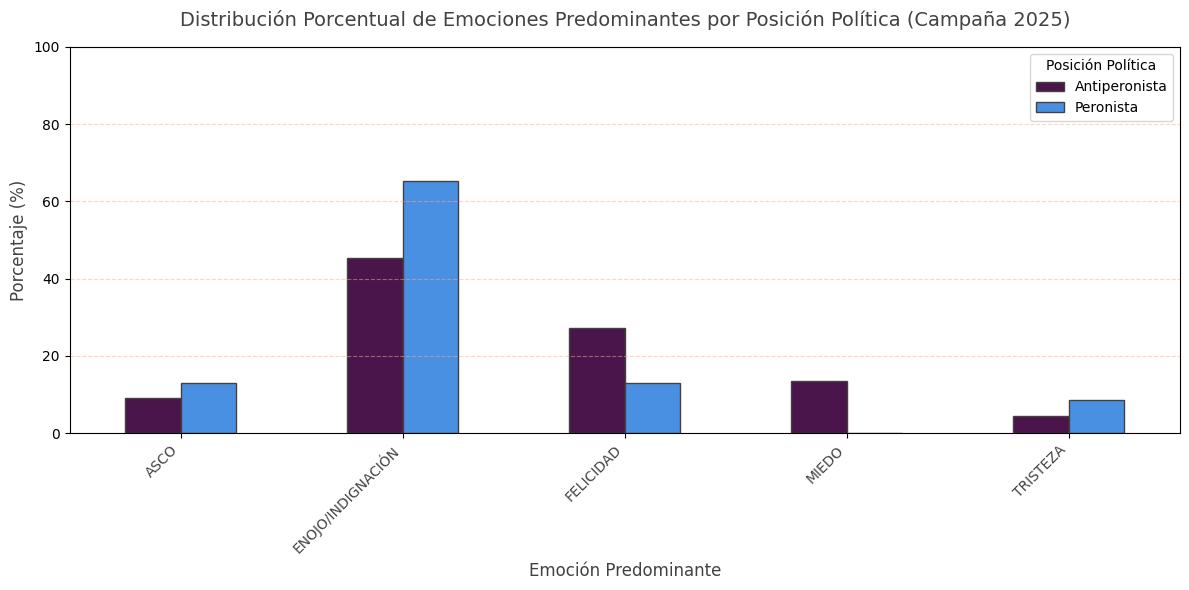

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Copia y unificación de Alegría en Felicidad para la campaña 2025
df_plot = df_campana_2025.copy()
df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
    'ALEGRÍA': 'FELICIDAD',
    'Alegría': 'FELICIDAD',
    'alegría': 'felicidad'
})

# Tabla cruzada para calcular porcentajes por posición política
tabla_emociones = pd.crosstab(df_plot['emoción_predominante'], df_plot['posición'], normalize='columns') * 100

# Definimos la lista de colores para las barras en el mismo orden de las columnas de la tabla
colores_barras = ['#4a154b', '#4a90e2'] # Ajusta el orden según corresponda a antiperonista/peronista

ax = tabla_emociones.plot(
    kind='bar',
    figsize=(12, 6),
    color=colores_barras,
    edgecolor='#444140',
    linewidth=1
)

plt.title('Distribución Porcentual de Emociones Predominantes por Posición Política (Campaña 2025)', fontsize=14, color='#444140', pad=15)
plt.xlabel('Emoción Predominante', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right', color='#444140')
plt.legend(title='Posición Política')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

## Promoción y detracción durante la campaña 2025

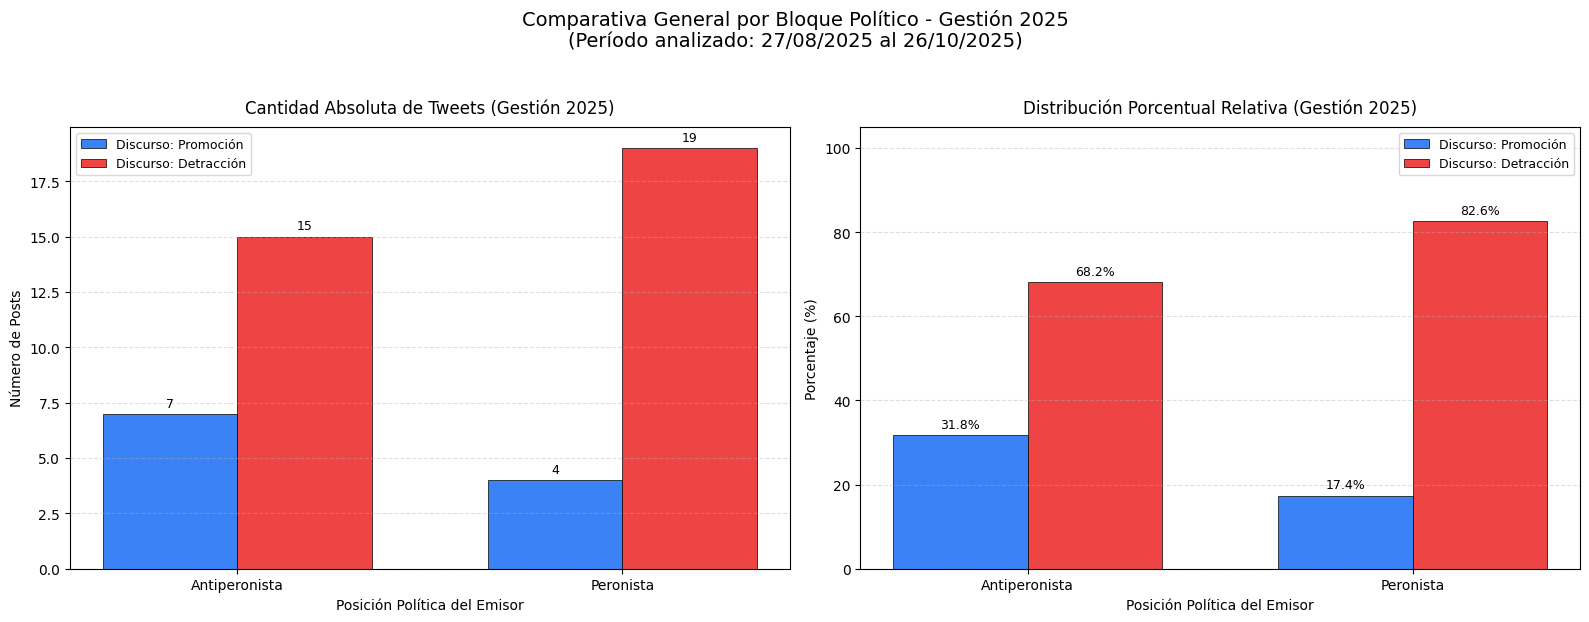

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Copia y preparación del DataFrame limpio usando df_campana_2025
df_plot = df_campana_2025.reset_index().copy()

# Normalizamos la columna objetivo
columna_objetivo = 'promoción/apoyo_o_detracción/ataque'
df_plot[columna_objetivo] = (
    df_plot[columna_objetivo]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'promocion': 'promoción',
        'detraccion': 'detracción'
    })
)

# Convertimos fechas para hallar el rango real
df_plot['fecha_dt'] = pd.to_datetime(df_plot['fecha'], errors='coerce')
fecha_min = df_plot['fecha_dt'].min().strftime('%d/%m/%Y')
fecha_max = df_plot['fecha_dt'].max().strftime('%d/%m/%Y')

# 2. Creamos la tabla cruzada general por posición y tipo de discurso
tabla_general = pd.crosstab(
    df_plot['posición'],
    df_plot[columna_objetivo]
)

# Aseguramos que existan ambas columnas (promoción y detracción)
categorias_fijas = ['promoción', 'detracción']
for cat in categorias_fijas:
    if cat not in tabla_general.columns:
        tabla_general[cat] = 0
tabla_general = tabla_general[categorias_fijas]

# Creamos también una tabla en porcentajes por fila para el segundo subplot
tabla_porcentual = tabla_general.div(tabla_general.sum(axis=1), axis=0) * 100

# 3. Configuración de la figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

posiciones = tabla_general.index
x = np.arange(len(posiciones))
ancho_barra = 0.35

colores_discurso = {
    'promoción': '#3b82f6',   # Azul
    'detracción': '#ef4444'   # Rojo
}

# --- PRIMER SUPLOT: Cantidad Absoluta de Posts ---
for i, tipo in enumerate(categorias_fijas):
    valores = tabla_general[tipo].values
    offset = (i - 0.5) * ancho_barra

    barras1 = ax1.bar(
        x + offset, valores, width=ancho_barra,
        label=f'Discurso: {tipo.capitalize()}',
        color=colores_discurso[tipo], edgecolor='black', linewidth=0.5
    )
    ax1.bar_label(barras1, padding=3, fontsize=9)

ax1.set_title('Cantidad Absoluta de Tweets (Gestión 2025)', fontsize=12, pad=10)
ax1.set_xlabel('Posición Política del Emisor', fontsize=10)
ax1.set_ylabel('Número de Posts', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(posiciones, rotation=0, fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4, axis='y')

# --- SEGUNDO SUPLOT: Distribución Porcentual (%) ---
for i, tipo in enumerate(categorias_fijas):
    valores = tabla_porcentual[tipo].values
    offset = (i - 0.5) * ancho_barra

    barras2 = ax2.bar(
        x + offset, valores, width=ancho_barra,
        label=f'Discurso: {tipo.capitalize()}',
        color=colores_discurso[tipo], edgecolor='black', linewidth=0.5
    )
    # Agregamos el "%" a las etiquetas
    ax2.bar_label(barras2, labels=[f'{v:.1f}%' for v in valores], padding=3, fontsize=9)

ax2.set_title('Distribución Porcentual Relativa (Gestión 2025)', fontsize=12, pad=10)
ax2.set_xlabel('Posición Política del Emisor', fontsize=10)
ax2.set_ylabel('Porcentaje (%)', fontsize=10)
ax2.set_ylim(0, 105) # Margen para que las etiquetas entren cómodas
ax2.set_xticks(x)
ax2.set_xticklabels(posiciones, rotation=0, fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4, axis='y')

# Título general para toda la figura indicando el período
fig.suptitle(f'Comparativa General por Bloque Político - Gestión 2025\n(Período analizado: {fecha_min} al {fecha_max})', fontsize=14, y=1.03)

plt.tight_layout()
plt.show()

## Emociones por endogrupo, referente propio, referente contrario y exogrupo durante la campaña 2025

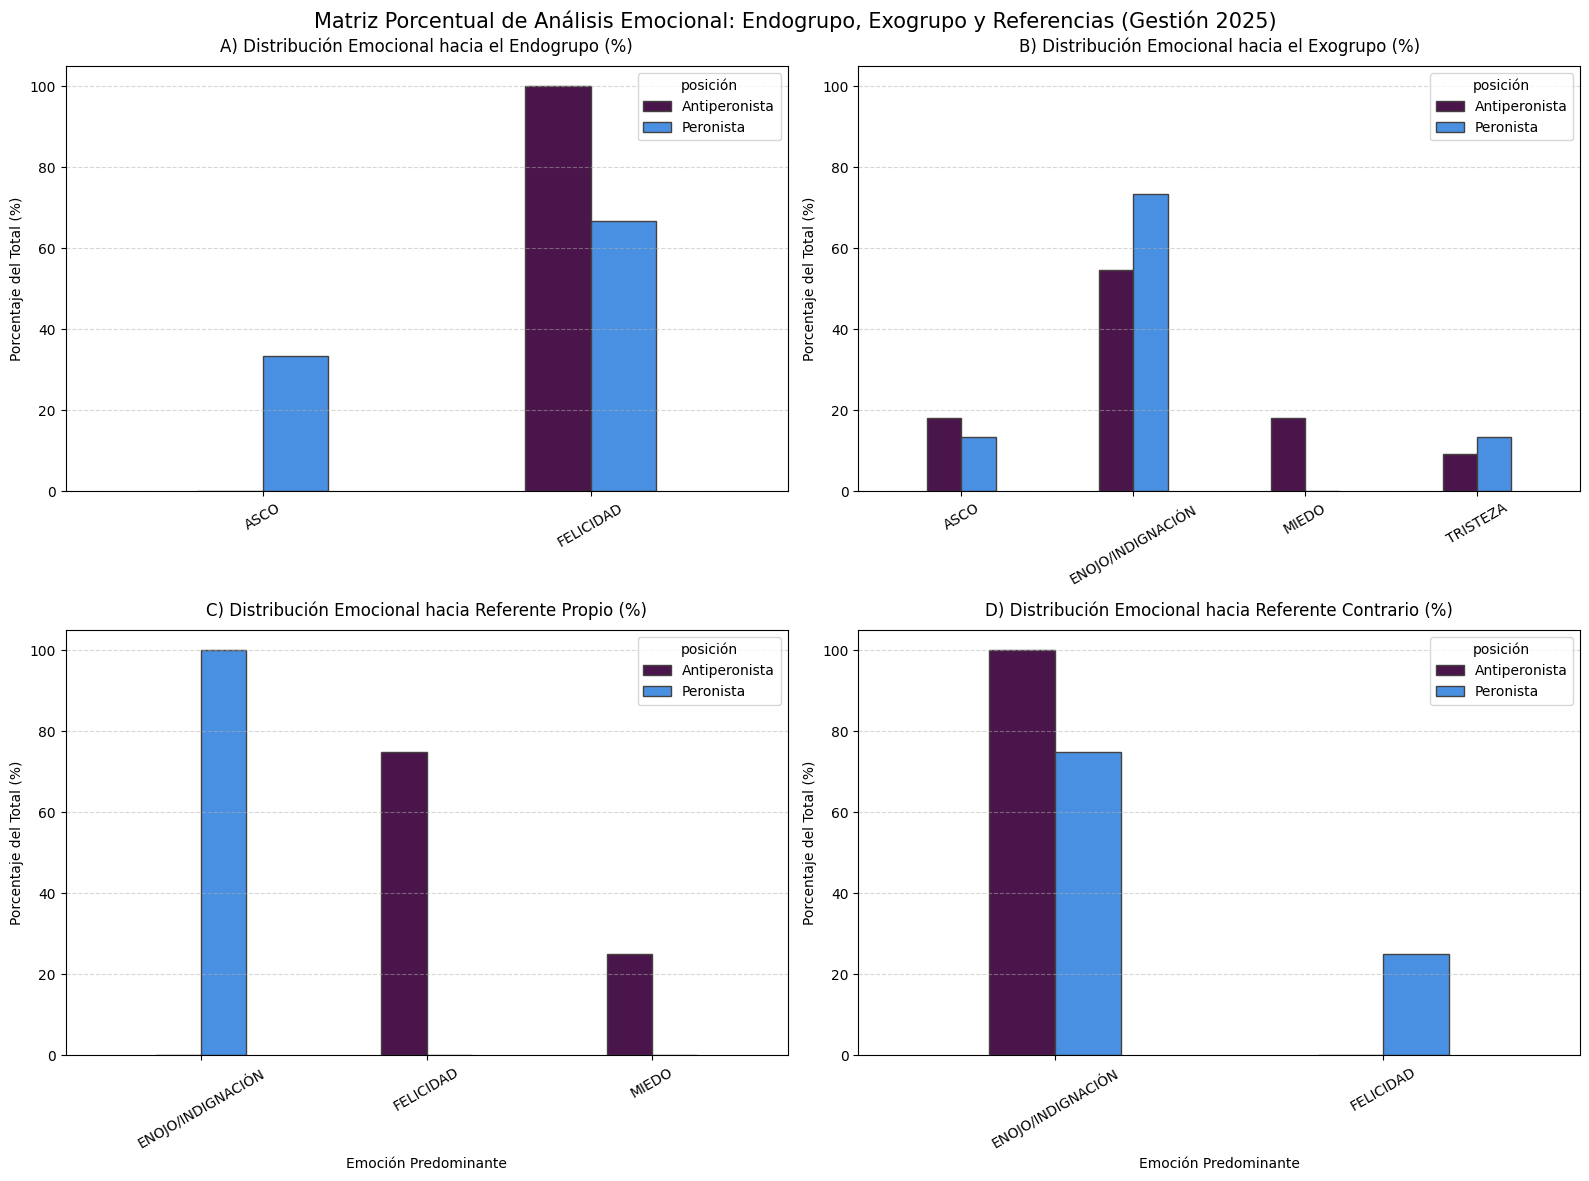

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Copia y preparación del DataFrame
df_plot = df_campana_2025.copy()

# Unificamos variantes de alegría en felicidad
df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
    'ALEGRÍA': 'FELICIDAD',
    'Alegría': 'FELICIDAD',
    'alegría': 'felicidad'
})

columna_destinatario = 'destinatario_de_la_promoción/detracción'
df_plot[columna_destinatario] = df_plot[columna_destinatario].astype(str).str.strip()

# 2. Creamos la tabla cruzada general desglosando por Emoción, Destinatario y Posición
tabla_emociones_destinatario = pd.pivot_table(
    df_plot,
    index='emoción_predominante',
    columns=[columna_destinatario, 'posición'],
    aggfunc='size',
    fill_value=0
)

# Convertimos los valores absolutos a porcentajes por cada columna
tabla_porcentual = tabla_emociones_destinatario.div(tabla_emociones_destinatario.sum(axis=0), axis=1) * 100

# 3. Configuración de la figura con 4 subplots en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax_endo, ax_exo = axes[0, 0], axes[0, 1]
ax_propio, ax_contrario = axes[1, 0], axes[1, 1]

colores_barras = ['#4a154b', '#4a90e2'] # Antiperonista y Peronista

# Función auxiliar para obtener y formatear estéticamente cada subplot
def graficar_subplot(ax, keyword, titulo, mostrar_xlabel=False):
    match_col = next((col for col in tabla_porcentual.columns.levels[0] if keyword.lower() in str(col).lower()), None)
    if match_col is not None:
        sub_df = tabla_porcentual[match_col]
        sub_df = sub_df[sub_df.sum(axis=1) > 0] # Filtramos filas vacías

        if not sub_df.empty:
            # Usamos width y position explícitos para controlar el ancho de las barras y evitar que se expandan
            sub_df.plot(
                kind='bar',
                ax=ax,
                color=colores_barras,
                edgecolor='#444140',
                linewidth=1,
                legend=True,
                width=0.4 # Controla la delgadez de las barras (más chico = más angostas)
            )
            ax.set_title(titulo, fontsize=12, pad=10)
            ax.set_xlabel('Emoción Predominante' if mostrar_xlabel else '', fontsize=10)
            ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)
            ax.set_ylim(0, 105)

            # Control de márgenes laterales en el eje X para que las barras no toquen los bordes
            ax.set_xlim(-0.6, len(sub_df) - 0.4)

            ax.tick_params(axis='x', rotation=30)
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            return

    ax.text(0.5, 0.5, f'Sin datos de {keyword.capitalize()}', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo, fontsize=12, pad=10)

# Aplicamos la función a cada cuadrante con su respectivo título actualizado a 2025
graficar_subplot(ax_endo, 'endogrupo', 'A) Distribución Emocional hacia el Endogrupo (%)', mostrar_xlabel=False)
graficar_subplot(ax_exo, 'exogrupo', 'B) Distribución Emocional hacia el Exogrupo (%)', mostrar_xlabel=False)
graficar_subplot(ax_propio, 'propio', 'C) Distribución Emocional hacia Referente Propio (%)', mostrar_xlabel=True)
graficar_subplot(ax_contrario, 'contrario', 'D) Distribución Emocional hacia Referente Contrario (%)', mostrar_xlabel=True)

# Título general de la figura
fig.suptitle('Matriz Porcentual de Análisis Emocional: Endogrupo, Exogrupo y Referencias (Gestión 2025)', fontsize=15, y=0.98)

plt.tight_layout()
plt.show()

## Frecuencia de destinatarios durante la campaña 2025

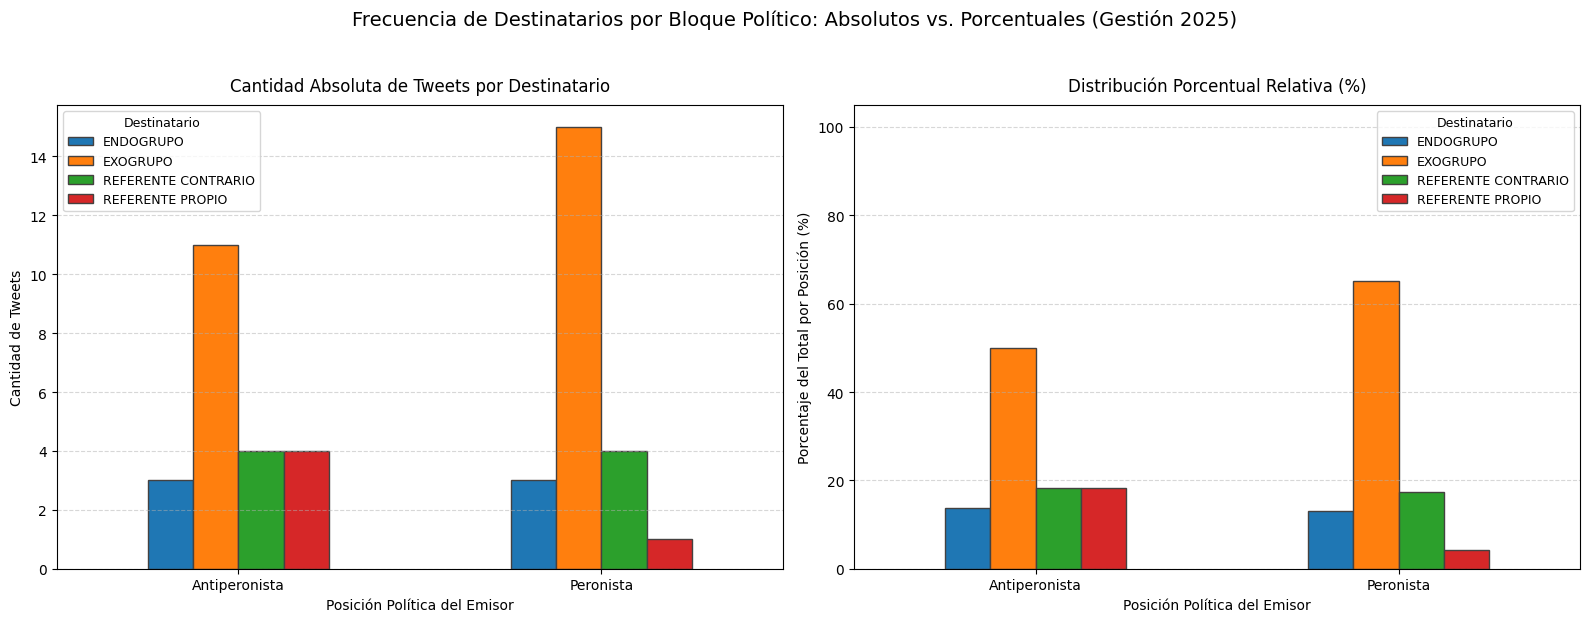

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Copia y preparación del DataFrame usando df_campana_2025
df_plot = df_campana_2025.copy()
columna_destinatario = 'destinatario_de_la_promoción/detracción'
df_plot[columna_destinatario] = df_plot[columna_destinatario].astype(str).str.strip()

# 2. Creamos la tabla cruzada general (Posición vs Destinatario)
tabla_absoluta = pd.crosstab(
    df_plot['posición'],
    df_plot[columna_destinatario]
)

# Creamos también la tabla en porcentajes por fila (para que cada posición sume 100%)
tabla_porcentual = tabla_absoluta.div(tabla_absoluta.sum(axis=1), axis=0) * 100

# 3. Configuración de la figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colores_barras = ['#4a154b', '#4a90e2'] # Ajustá según tus posiciones políticas

# --- SUBPLOT 1: CANTIDAD ABSOLUTA ---
tabla_absoluta.plot(
    kind='bar',
    ax=ax1,
    edgecolor='#444140',
    linewidth=1,
    rot=0
)
ax1.set_title('Cantidad Absoluta de Tweets por Destinatario', fontsize=12, pad=10)
ax1.set_xlabel('Posición Política del Emisor', fontsize=10)
ax1.set_ylabel('Cantidad de Tweets', fontsize=10)
ax1.legend(title='Destinatario', fontsize=9, title_fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- SUBPLOT 2: DISTRIBUCIÓN PORCENTUAL ---
tabla_porcentual.plot(
    kind='bar',
    ax=ax2,
    edgecolor='#444140',
    linewidth=1,
    rot=0
)
ax2.set_title('Distribución Porcentual Relativa (%)', fontsize=12, pad=10)
ax2.set_xlabel('Posición Política del Emisor', fontsize=10)
ax2.set_ylabel('Porcentaje del Total por Posición (%)', fontsize=10)
ax2.set_ylim(0, 105) # Margen cómodo para las etiquetas o lectura visual
ax2.legend(title='Destinatario', fontsize=9, title_fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Título general actualizado para 2025
fig.suptitle('Frecuencia de Destinatarios por Bloque Político: Absolutos vs. Porcentuales (Gestión 2025)', fontsize=14, y=1.03)

plt.tight_layout()
plt.show()

# Evolución emociones

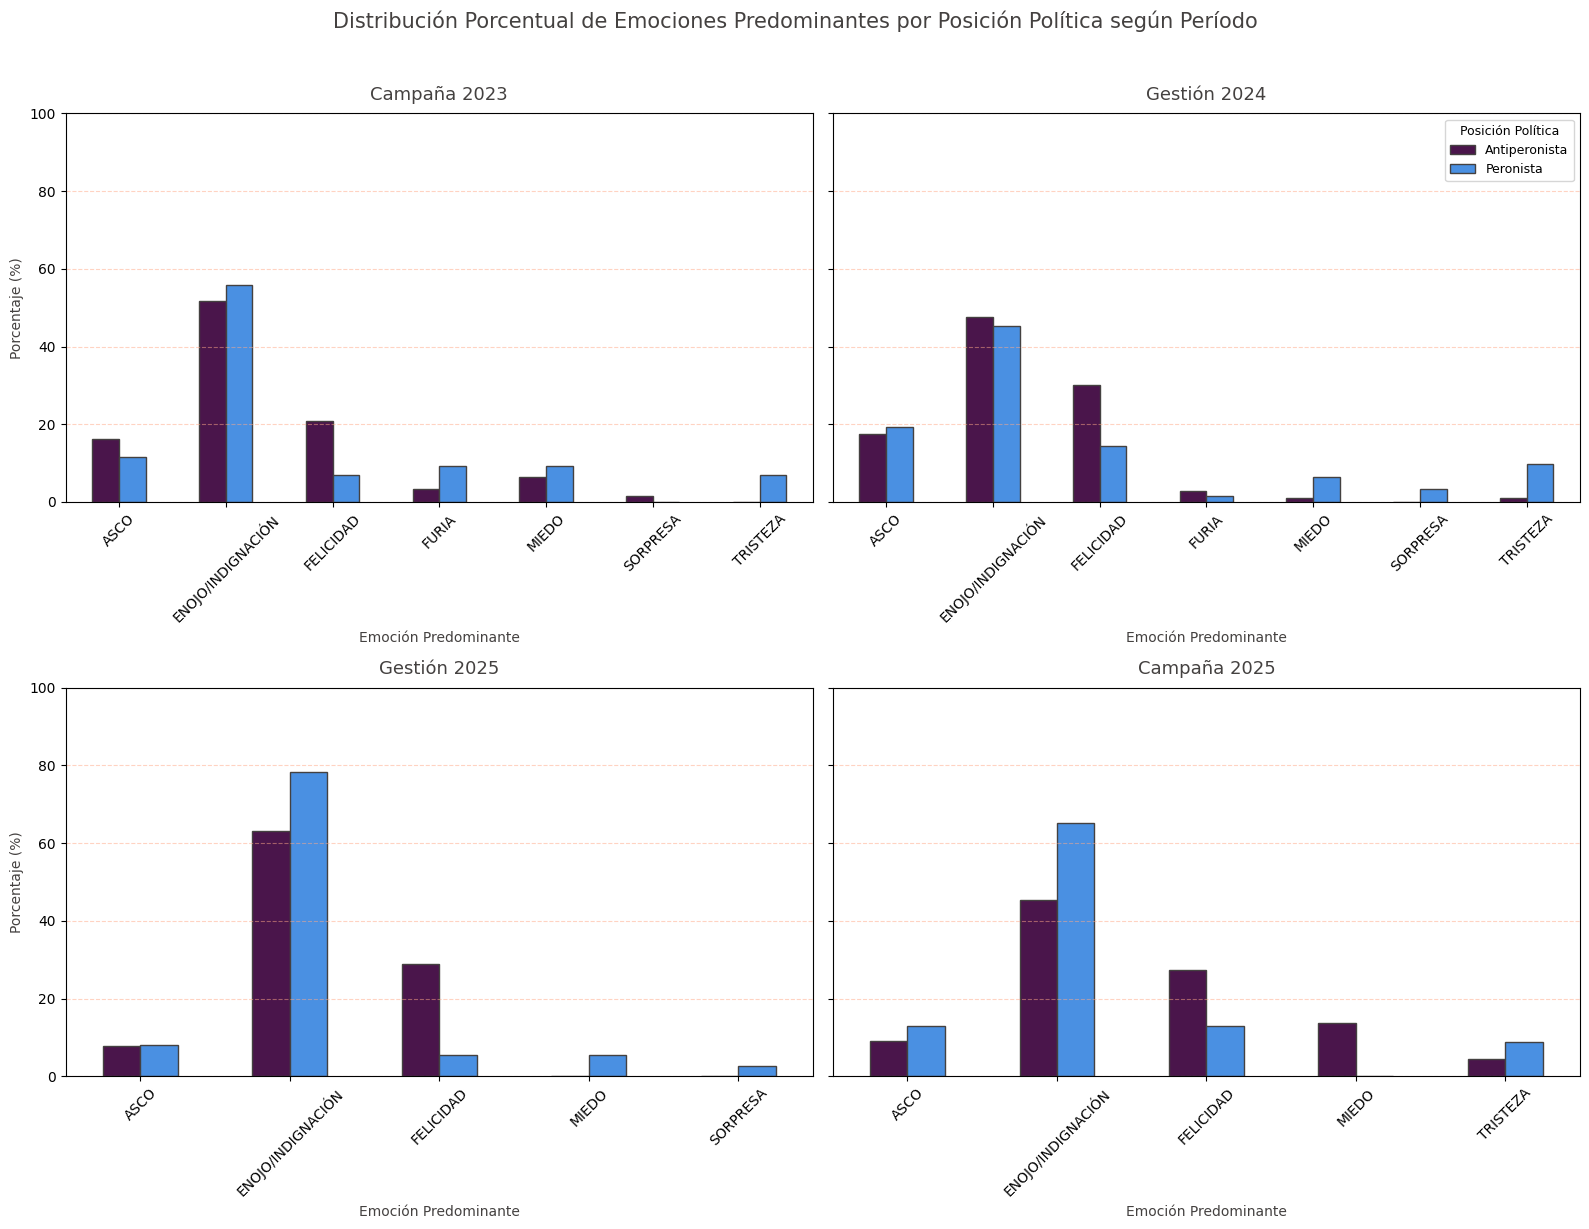

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

# Definimos los dataframes y sus respectivos títulos para los 4 subplots
periodos = [
    (df_campana_2023, 'Campaña 2023'),
    (df_gestion_2024, 'Gestión 2024'),
    (df_gestion_2025, 'Gestión 2025'),
    (df_campana_2025, 'Campaña 2025')
]

# Creamos una figura con una cuadrícula de 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten() # Aplanamos para recorrerlos fácilmente con un bucle

colores_barras = ['#4a154b', '#4a90e2'] # antiperonista / peronista

for i, (df_actual, titulo_periodo) in enumerate(periodos):
    ax = axes[i]

    # Copia y unificación de Alegría en Felicidad
    df_plot = df_actual.copy()
    if 'emoción_predominante' in df_plot.columns:
        df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
            'ALEGRÍA': 'FELICIDAD',
            'Alegría': 'FELICIDAD',
            'alegría': 'felicidad'
        })

    # Tabla cruzada normalizada en porcentaje por posición política
    tabla_emociones = pd.crosstab(
        df_plot['emoción_predominante'],
        df_plot['posición'],
        normalize='columns'
    ) * 100

    # Graficar en el subplot correspondiente
    tabla_emociones.plot(
        kind='bar',
        ax=ax,
        color=colores_barras,
        edgecolor='#444140',
        linewidth=1,
        legend=(i == 1) # Mostramos la leyenda solo en un subplot para que no se sature
    )

    ax.set_title(f'{titulo_periodo}', fontsize=13, color='#444140', pad=10)
    ax.set_xlabel('Emoción Predominante', fontsize=10, color='#444140')
    ax.set_ylabel('Porcentaje (%)', fontsize=10, color='#444140')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')

    # Ajuste de leyenda si se muestra
    if i == 1:
        ax.legend(title='Posición Política', fontsize=9, title_fontsize=9, loc='upper right')

# Título general de la figura
fig.suptitle('Distribución Porcentual de Emociones Predominantes por Posición Política según Período', fontsize=15, color='#444140', y=1.02)

plt.tight_layout()
plt.show()

# Evolución detracción y promoción

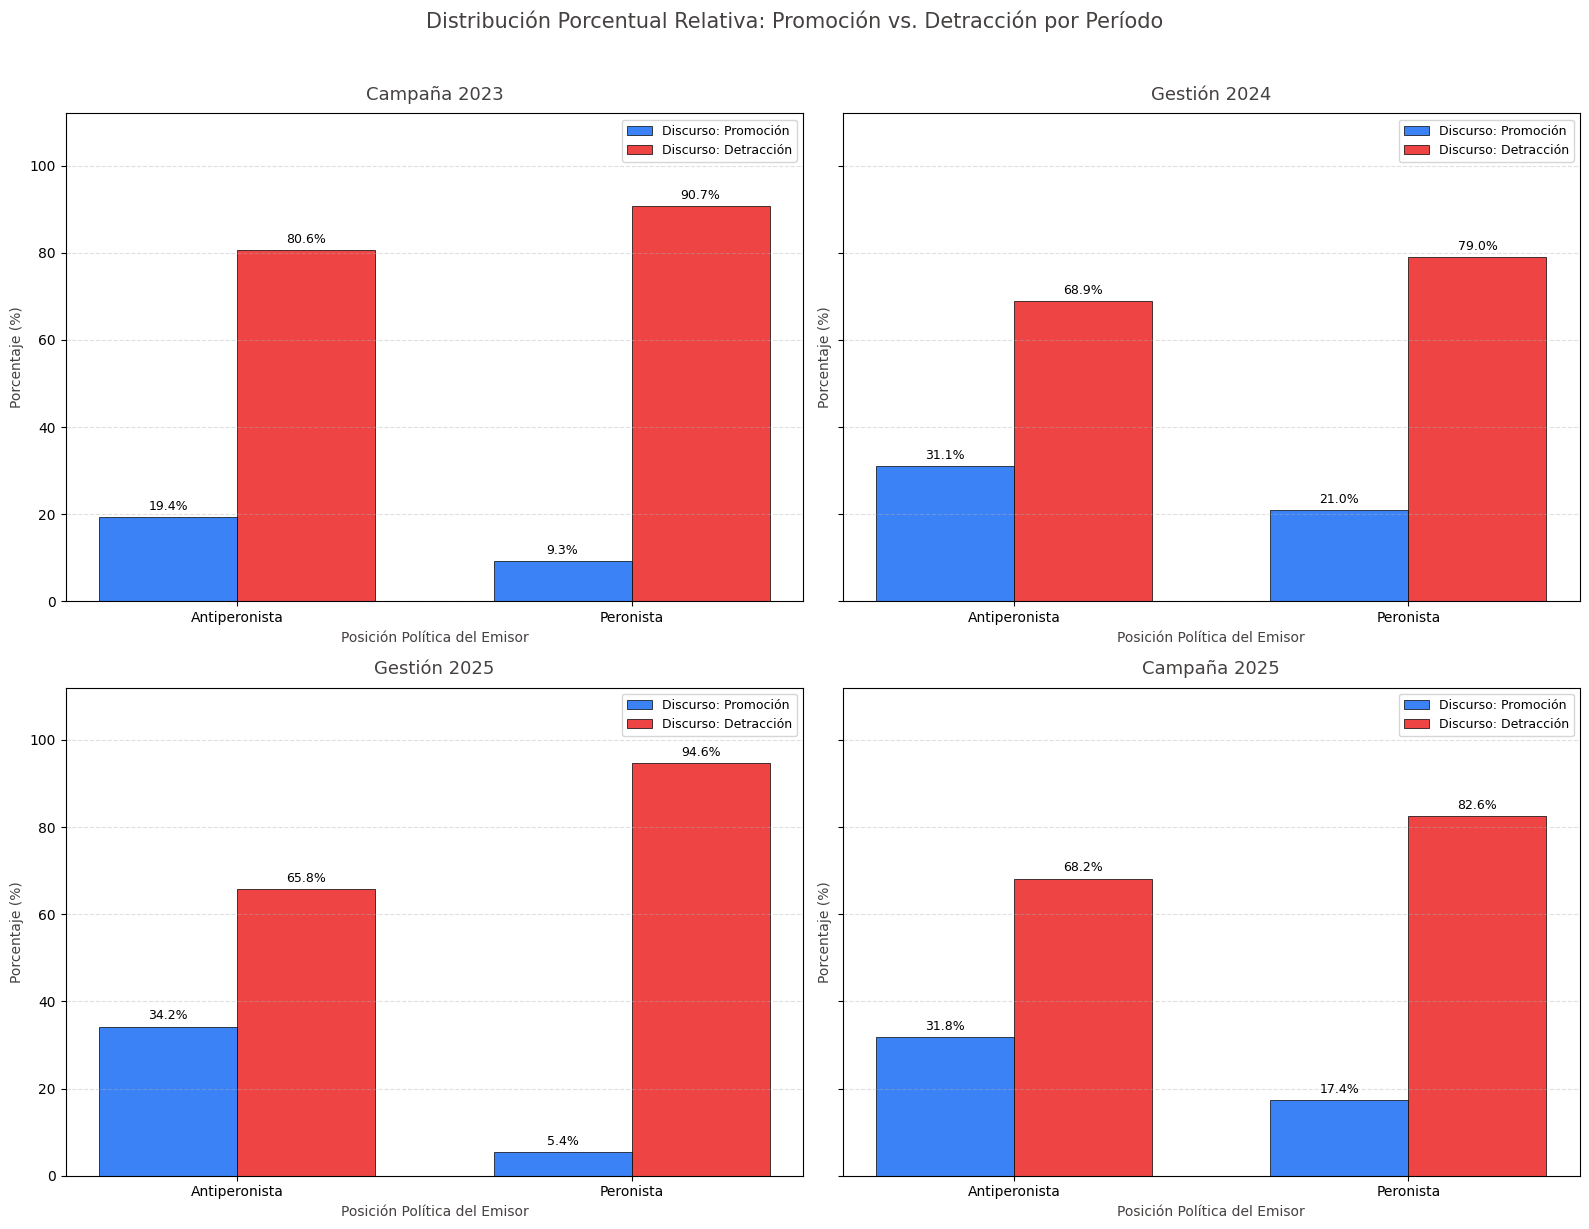

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Definimos los dataframes y sus respectivos títulos para los 4 subplots
periodos = [
    (df_campana_2023, "Campaña 2023"),
    (df_gestion_2024, "Gestión 2024"),
    (df_gestion_2025, "Gestión 2025"),
    (df_campana_2025, "Campaña 2025"),
]

# Creamos una figura con una cuadrícula de 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()  # Aplanamos para recorrerlos fácilmente con un bucle

colores_discurso = {
    "promoción": "#3b82f6",  # Azul
    "detracción": "#ef4444",  # Rojo
}
categorias_fijas = ["promoción", "detracción"]

for i, (df_actual, titulo_periodo) in enumerate(periodos):
  ax = axes[i]

  # 1. Copia y preparación del DataFrame limpio para el período actual
  df_plot = df_actual.reset_index().copy()

  columna_objetivo = "promoción/apoyo_o_detracción/ataque"
  df_plot[columna_objetivo] = (
      df_plot[columna_objetivo]
      .astype(str)
      .str.strip()
      .str.lower()
      .replace({"promocion": "promoción", "detraccion": "detracción"})
  )

  # 2. Creamos la tabla cruzada y aseguramos las categorías fijas
  tabla_general = pd.crosstab(df_plot["posición"], df_plot[columna_objetivo])

  for cat in categorias_fijas:
    if cat not in tabla_general.columns:
      tabla_general[cat] = 0
  tabla_general = tabla_general[categorias_fijas]

  # Calculamos la tabla porcentual por fila
  tabla_porcentual = tabla_general.div(tabla_general.sum(axis=1), axis=0) * 100

  posiciones = tabla_general.index
  x = np.arange(len(posiciones))
  ancho_barra = 0.35

  # 3. Gráfico de barras porcentuales para este subplot
  for j, tipo in enumerate(categorias_fijas):
    valores = tabla_porcentual[tipo].values
    offset = (j - 0.5) * ancho_barra

    barras = ax.bar(
        x + offset,
        valores,
        width=ancho_barra,
        label=f"Discurso: {tipo.capitalize()}",
        color=colores_discurso[tipo],
        edgecolor="black",
        linewidth=0.5,
    )
    # Agregamos las etiquetas con porcentaje, manejando posibles NaN si algún grupo está vacío
    ax.bar_label(
        barras,
        labels=[f"{v:.1f}%" if not np.isnan(v) else "0.0%" for v in valores],
        padding=3,
        fontsize=9,
    )

  ax.set_title(f"{titulo_periodo}", fontsize=13, pad=10, color="#444140")
  ax.set_xlabel("Posición Política del Emisor", fontsize=10, color="#444140")
  ax.set_ylabel("Porcentaje (%)", fontsize=10, color="#444140")
  ax.set_ylim(
      0, 112
  )  # Margen superior para que las etiquetas de porcentaje no queden cortadas
  ax.set_xticks(x)
  ax.set_xticklabels(posiciones, rotation=0, fontsize=10)
  ax.legend(fontsize=9, loc="upper right")
  ax.grid(True, linestyle="--", alpha=0.4, axis="y")

# Título general de la figura
fig.suptitle(
    "Distribución Porcentual Relativa: Promoción vs. Detracción por Período",
    fontsize=15,
    color="#444140",
    y=1.02,
)

plt.tight_layout()
plt.show()

# Evolución de la frecuencia por destinatario en los 4 bloques

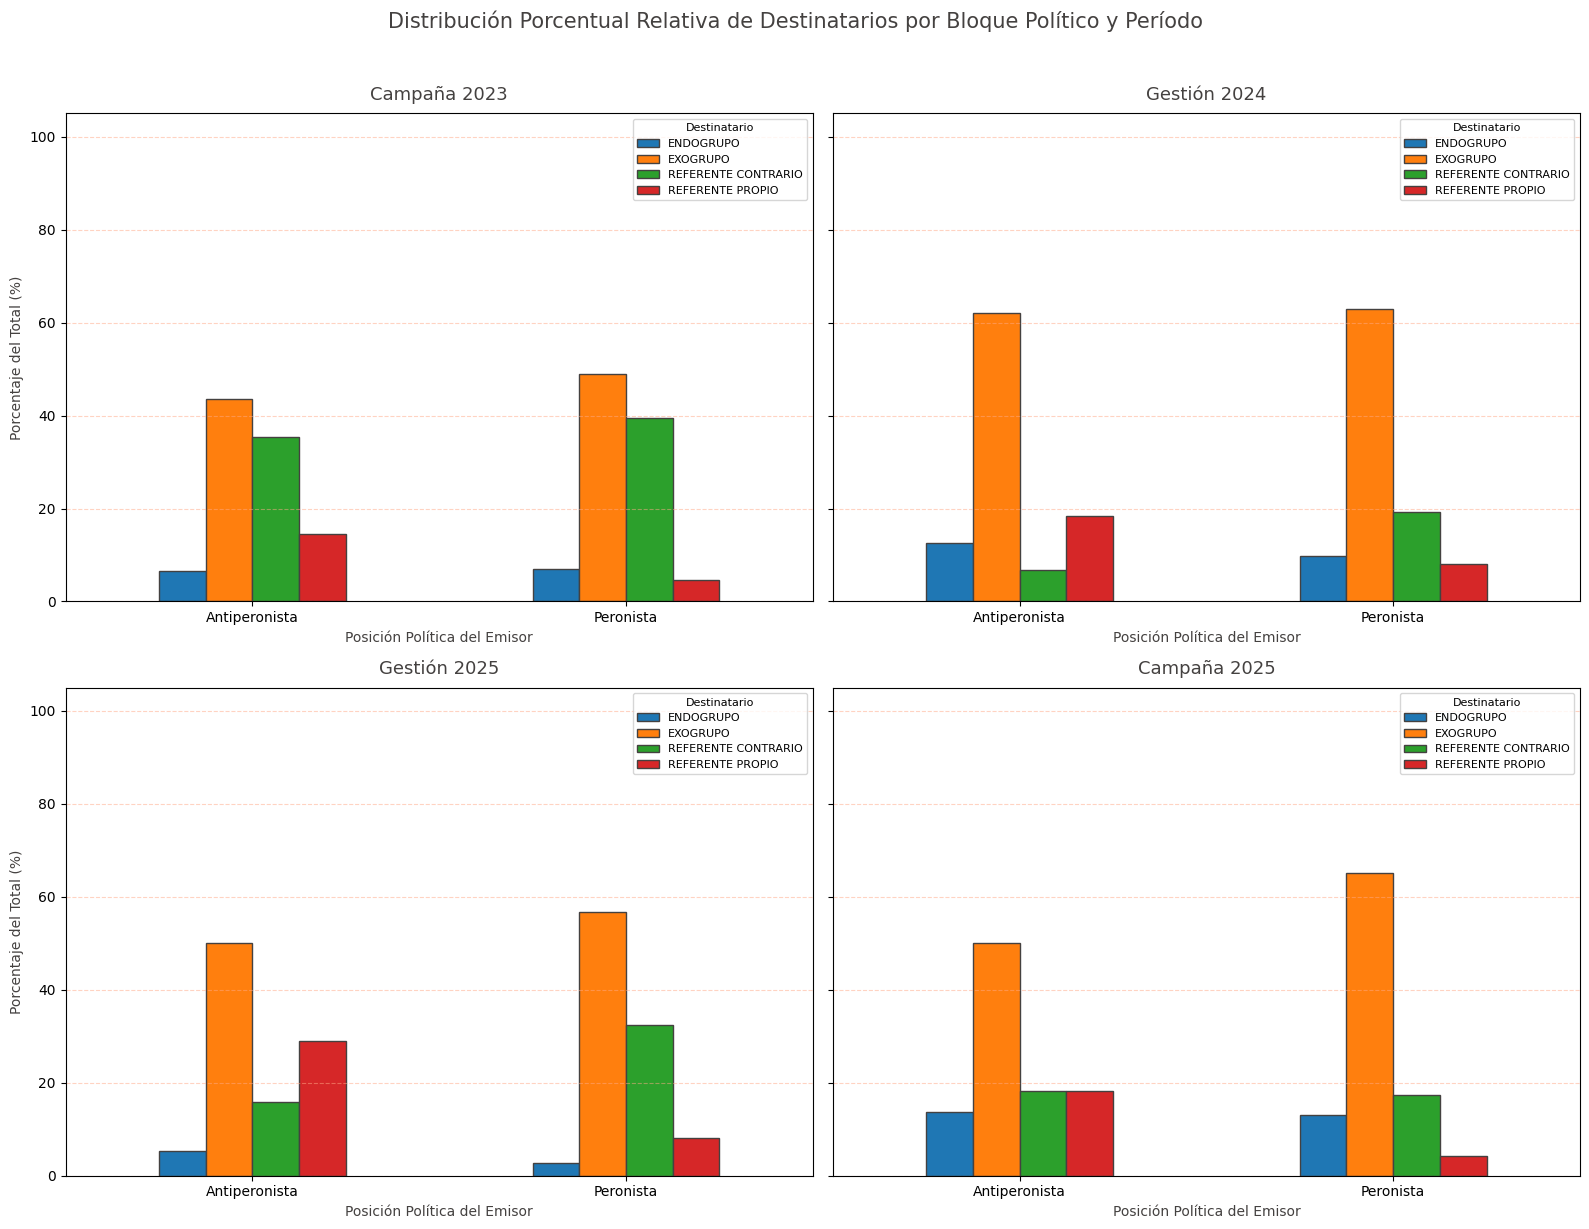

In [63]:
import matplotlib.pyplot as plt
import pandas as pd

# Definimos los dataframes y sus respectivos títulos para los 4 subplots
periodos = [
    (df_campana_2023, 'Campaña 2023'),
    (df_gestion_2024, 'Gestión 2024'),
    (df_gestion_2025, 'Gestión 2025'),
    (df_campana_2025, 'Campaña 2025')
]

# Creamos una figura con una cuadrícula de 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()  # Aplanamos para recorrerlos fácilmente con un bucle

columna_destinatario = 'destinatario_de_la_promoción/detracción'

for i, (df_actual, titulo_periodo) in enumerate(periodos):
    ax = axes[i]

    # 1. Copia y preparación del DataFrame para el período actual
    df_plot = df_actual.copy()

    # Limpiamos y unificamos el error tipográfico de "cotnrario" a "contrario"
    if columna_destinatario in df_plot.columns:
        df_plot[columna_destinatario] = (
            df_plot[columna_destinatario]
            .astype(str)
            .str.strip()
            .replace({
                'REFERENTE COTNRARIO': 'REFERENTE CONTRARIO',
                'referente cotnrario': 'referente contrario',
                'Referente cotnrario': 'Referente contrario'
            })
        )

    # 2. Creamos la tabla cruzada general (Posición vs Destinatario)
    tabla_absoluta = pd.crosstab(
        df_plot['posición'],
        df_plot[columna_destinatario]
    )

    # Creamos la tabla en porcentajes por fila (para que cada posición sume 100%)
    tabla_porcentual = tabla_absoluta.div(tabla_absoluta.sum(axis=1), axis=0) * 100

    # 3. Gráfico de barras exclusivamente porcentual para este subplot
    tabla_porcentual.plot(
        kind='bar',
        ax=ax,
        edgecolor='#444140',
        linewidth=1,
        rot=0
    )

    ax.set_title(f'{titulo_periodo}', fontsize=13, pad=10, color='#444140')
    ax.set_xlabel('Posición Política del Emisor', fontsize=10, color='#444140')
    ax.set_ylabel('Porcentaje del Total (%)', fontsize=10, color='#444140')
    ax.set_ylim(0, 105)  # Margen cómodo para lectura visual
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')

    # Mostramos la leyenda ordenada en todos los subplots (o ajustala si querés que aparezca en uno solo)
    ax.legend(title='Destinatario', fontsize=8, title_fontsize=8, loc='upper right')

# Título general de la figura
fig.suptitle('Distribución Porcentual Relativa de Destinatarios por Bloque Político y Período', fontsize=15, color='#444140', y=1.02)

plt.tight_layout()
plt.show()